In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 72 

In [2]:
o_df = pd.read_csv('../data/processed/smartphones_cleaned.csv')

#### GOAL ?
  - to identify the hidden pattern lying inside the data
  - to understand the effect of other parameters on price
  - to extract meaningful insights from data

## Points
  - why single sim are so costlier ? <br>
  <b>ANS : </b> because single sim is led primarily by apple iphones and some of the foldable premium phones so that's why their prices are higher <br>
  <b>Added : </b> only 6 phones are single sim (iPhone 8, iPhone 8 Plus, Galaxy Z Flip 5, Motorola Razr 2019), so this is a very small group. It is not a real trend

  - [Vo5G, NFC, eSIM] have [weak, strong, weak] correlation with price respectively <br>
  <b>Correction : </b> when I check the actual numbers all three go with a higher price (median price with vs without: Vo5G 56k vs 25k, NFC 45k vs 19k, eSIM 77k vs 25k). eSIM has the biggest gap but only 131 phones have it, NFC is the one that most phones have (397), so NFC is the most useful of the three

  - as the number of cores is increasing the price is also increasing but the one number does not fit in linearity that is 6 cores also 1 & 2 cores processors have price greater than 4 why ? <br>
  <b> ANS: </b> 6 cores is used by apple iphones (all 31 hexa-core phones are iPhones). 1 and 2 core phones have only 7 and 1 phones and 4 core has only 6 old cheap phones, so these groups are too small to trust

  - why 2gb ram phones show a higher average price than 3gb and 4gb ? <br>
  <b> ANS: </b> because apple iphone 8 (price 77000) is in the 2gb group, and there are only 7 phones in that group so the mean was pulled up. The median price goes in the right order (7.5k, 10.4k, 14k) <br>
  <b>Added : </b> same reason for 18gb < 16gb, there is only one 18gb phone (ASUS ROG Phone 5s Pro, 79,999)

  - why there are no battery values between 8000 - 9000 and between 9020 - 10001 ? <br>
  <b> ANS: </b> only 34 phones are above 8000 mAh and they come at only 4 values (8000, 9000, 9020, 10001). These are new big batteries and companies launch them with round numbers, so nothing is in between. It can also be that the dataset is missing some phones, which we cannot confirm from this data

  - why are some rows empty in the correlation heatmap (Vo5G, NFC, eSIM, IR_Blaster, isFoldable, isDualDisplay) ? <br>
  <b> ANS: </b> these columns have only 1 or NaN, so correlation cannot be calculated. They need fillna(0) first (done in the multivariate section)

  - why Bionic and Apple were counted as two different processor brands ? <br>
  <b> ANS: </b> replace() only changes the exact word 'Bionic' but names like 'Bionic A16' kept the word after the split. Fixed in the cleaning part

In [3]:
o_df.columns

Index(['Name', 'Specs', 'Price', 'Rating', 'sim_original', 'Processor', 'Ram',
       'Battery', 'Display', 'Camera', 'Card', 'Os', 'Brand', 'SIM', 'Network',
       'VoLTE', 'Vo5G', 'NFC', 'eSIM', 'Wi-Fi', 'IR_Blaster', 'processor_name',
       'processor_cores', 'processor_clock_speed(GHz)', 'ram(GB)',
       'storage(GB)', 'battery(mAh)', 'charging_support(W)', 'display_size',
       'display_resolution', 'refresh_rate(Hz)', 'display_design',
       'isFoldable', 'isDualDisplay', 'rear_main_camera', 'rear_camera_count',
       'front_main_camera', 'front_camera_count', 'rear_total_mp',
       'front_total_mp', 'card_supported', 'card_type', 'card_capacity(GB)'],
      dtype='object')

In [4]:
# inspecting the data
o_df.info()
o_df.dtypes
o_df.describe().round(4)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 919 entries, 0 to 918
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Name                        919 non-null    object 
 1   Specs                       919 non-null    int64  
 2   Price                       919 non-null    int64  
 3   Rating                      919 non-null    float64
 4   sim_original                919 non-null    object 
 5   Processor                   919 non-null    object 
 6   Ram                         919 non-null    object 
 7   Battery                     919 non-null    object 
 8   Display                     919 non-null    object 
 9   Camera                      919 non-null    object 
 10  Card                        667 non-null    object 
 11  Os                          891 non-null    object 
 12  Brand                       919 non-null    object 
 13  SIM                         919 non

,Specs,Price,Rating,VoLTE,Vo5G,NFC,eSIM,Wi-Fi,IR_Blaster,processor_clock_speed(GHz),...,refresh_rate(Hz),isFoldable,isDualDisplay,rear_camera_count,front_main_camera,front_camera_count,rear_total_mp,front_total_mp,card_supported,card_capacity(GB)
count,919.0000,919.0000,919.0000,919.0,142.0,397.0,131.0,919.0,288.0,867.0000,...,816.0000,38.0,42.0,919.0000,913.0000,919.0000,919.0000,913.0000,667.0000,355.0000
mean,63.6235,37735.9761,4.3639,1.0,1.0,1.0,1.0,1.0,1.0,2.6677,...,119.8860,1.0,1.0,2.3482,19.3590,1.0120,71.2548,19.7205,0.6867,1205.3408
std,14.2282,34464.3123,0.2320,0.0,0.0,0.0,0.0,0.0,0.0,0.6331,...,15.1941,0.0,0.0,0.7631,14.0896,0.1578,51.6962,14.3938,0.4642,571.9258
min,17.0000,5700.0000,3.7500,1.0,1.0,1.0,1.0,1.0,1.0,0.5120,...,60.0000,1.0,1.0,1.0000,2.0000,0.0000,5.0000,2.0000,0.0000,128.0000
25%,54.0000,17499.0000,4.1500,1.0,1.0,1.0,1.0,1.0,1.0,2.4000,...,120.0000,1.0,1.0,2.0000,8.0000,1.0000,50.0000,8.0000,0.0000,1000.0000
50%,63.0000,26999.0000,4.3500,1.0,1.0,1.0,1.0,1.0,1.0,2.5000,...,120.0000,1.0,1.0,2.0000,13.0000,1.0000,58.0000,16.0000,1.0000,1000.0000
75%,74.0000,42499.0000,4.5500,1.0,1.0,1.0,1.0,1.0,1.0,2.9600,...,120.0000,1.0,1.0,3.0000,32.0000,1.0000,73.5000,32.0000,1.0000,2000.0000
max,98.0000,259999.0000,4.7500,1.0,1.0,1.0,1.0,1.0,1.0,4.7400,...,165.0000,1.0,1.0,5.0000,50.0000,2.0000,450.0000,64.0000,1.0000,2000.0000


After inspecting the data it has been observed that some of the columns can not be of any help as a result they have been discarded

In [5]:
original_columns = o_df.columns
excluded_columns = ['index', 'sim_original', 'Processor', 'Ram', 'Battery', 'Display', 'Camera', 'Card', 'Os', 'VoLTE', 'Wi-Fi']
new_columns = []
for col in original_columns:
    if not col in excluded_columns:
        new_columns.append(col)
df = o_df[new_columns].copy()   # .copy() added, this removes the SettingWithCopyWarning from the next cell

Observation shows that some columns had dtype fundamentally wrong so they were converted, and columns like processor_name can be of better help if it were processor_brand so, it has to be converted

In [6]:
temp = ['battery(mAh)', 'charging_support(W)', 'rear_main_camera'] # columns whose dtype is wrong

df['Network'] = df['Network'].str.strip().str.split("G").str[0].str.strip().astype('Int64')
df.loc[df['charging_support(W)'] == 'Unknown', 'charging_support(W)'] = np.nan
df.loc[df['battery(mAh)'] == 'Unknown', 'battery(mAh)'] = np.nan
df.loc[df['rear_main_camera'] == '\n', 'rear_main_camera'] = np.nan

# change the dtypes
for col in temp:
    if col == 'rear_main_camera':
        df[col] = df[col].astype('Float64', errors='ignore')
    else :
        df[col] = df[col].astype('Int64')
        
        
processor_cores_map = {
    'Octa Core':8,
    'Hexa Core':6,
    'Single Core':1,
    'Deca Core':10,
    'Nine Cores':9,
    'Quad Core':4,
    'Dual Core':2,
}
df['processor_cores'] = df['processor_cores'].replace(processor_cores_map)

df['processor_name'] = df['processor_name'].str.strip().str.title()
replace_map = {
    'Unknkown': 'Unknown',
    'Tiger': 'Unisoc',
    'Mtk6739': 'Mediatek',
    'Mt8125': 'Mediatek',
    'Mtk6763': 'Mediatek',
    'Bionic': 'Apple',
}
df['processor_name'] = df['processor_name'].replace(replace_map)
df['processor_name'] = df['processor_name'].replace('Unknown', np.nan)
df['processor_name'] = df['processor_name'].str.split(" ").str[0]

df = df.rename(columns={
    'processor_name':'processor_brand'
})

x = df.dtypes.reset_index()
object_columns=x[x[0] == 'object']['index']
df[object_columns]

df = df[~(df.index.isin([625, 759]))]

df.loc[df['display_design'] == ' Dynamic Island Display', 'display_design'] = ' Dynamic Island'

df = df.drop(columns=['rear_total_mp', 'front_total_mp'])

C:\Users\Asus\AppData\Local\Temp\ipykernel_4396\237903371.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['processor_cores'] = df['processor_cores'].replace(processor_cores_map)


In [7]:
before = df['processor_brand'].value_counts()
df['processor_brand'] = df['processor_brand'].replace('Bionic', 'Apple')
after = df['processor_brand'].value_counts()

pd.concat([before, after], axis=1, keys=['before', 'after']).fillna(0).astype(int)

,before,after
processor_brand,,
Dimensity,362,362
Snapdragon,306,306
Exynos,67,67
Unisoc,67,67
Helio,56,56
Tensor,19,19
Apple,17,31
Bionic,14,0
Mediatek,6,6


In [8]:
df['processor_cores'] = pd.to_numeric(df['processor_cores'])

In [9]:
missing = pd.concat([df.isna().sum(), (df.isna().mean() * 100).round(1)], axis=1, keys=['missing', 'percent'])
missing[missing['missing'] > 0].sort_values('missing', ascending=False)

,missing,percent
isFoldable,879,95.9
isDualDisplay,875,95.4
eSIM,786,85.7
Vo5G,775,84.5
IR_Blaster,629,68.6
card_capacity(GB),563,61.4
NFC,520,56.7
card_type,460,50.2
card_supported,251,27.4
refresh_rate(Hz),101,11.0


## UNIVARIATE ANALYSIS

count       917.000000
mean      37797.670665
std       34476.533642
min        5700.000000
25%       17799.000000
50%       26999.000000
75%       42999.000000
max      259999.000000
Name: Price, dtype: float64


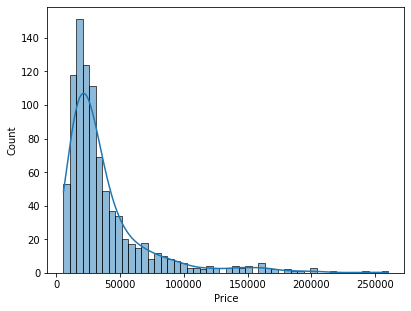

Skewness:  2.636230344777166


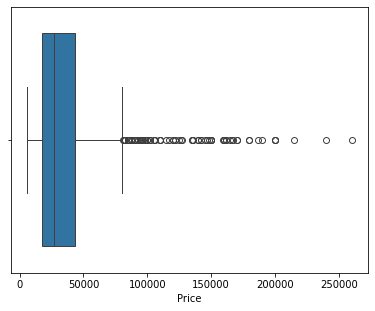

,Name,Specs,Price,Rating,Brand,SIM,Network,Vo5G,NFC,eSIM,...,display_design,isFoldable,isDualDisplay,rear_main_camera,rear_camera_count,front_main_camera,front_camera_count,card_supported,card_type,card_capacity(GB)
315,Samsung Galaxy Z Fold 8 Ultra,98,259999,4.35,Samsung,Dual Sim,5,1.0,1.0,1.0,...,Punch Hole,1.0,1.0,<NA>,3,10.0,2,NaN,NaN,NaN
548,Samsung Galaxy Z Fold 8 Ultra,95,214999,4.15,Samsung,Dual Sim,5,1.0,1.0,1.0,...,Punch Hole,1.0,1.0,<NA>,3,10.0,2,NaN,NaN,NaN
627,Samsung Galaxy Z Fold 8,94,239999,4.00,Samsung,Dual Sim,5,1.0,1.0,1.0,...,Punch Hole,1.0,1.0,<NA>,2,10.0,2,NaN,NaN,NaN


In [10]:
print(df['Price'].describe())
sns.histplot(data=df, x='Price', kde=True)
plt.show()
print("Skewness: ", df['Price'].skew())
sns.boxplot(data=df, x='Price')
plt.show()

df[df['Price']>200000]

count    917.000000
mean      63.702290
std       14.143129
min       17.000000
25%       54.000000
50%       63.000000
75%       74.000000
max       98.000000
Name: Specs, dtype: float64
skewness:  0.0489


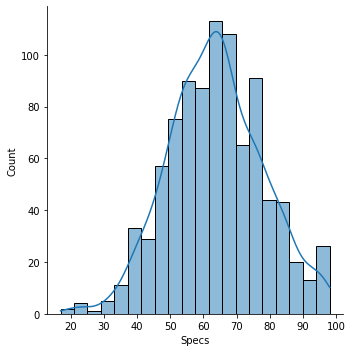

<Axes: xlabel='Specs'>

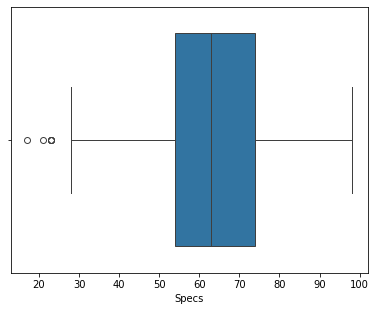

In [11]:
print(df['Specs'].describe())
print("skewness: ", df['Specs'].skew().round(4)) # type: ignore
sns.displot(kind='hist', kde=True, data=df,x='Specs')
plt.show()
sns.boxplot(data=df, x='Specs')
# df = df[~(df['Specs']<25)]

In [12]:
df[df['Specs'] < 25][['Name', 'Price', 'Specs', 'Brand']]

,Name,Price,Specs,Brand
274,Ringme Bold 17 Mini,6299,23,Ringme
501,Peace Honor 20,5800,23,Peace
584,MTR M16 Pro,5700,17,Mtr
763,Peace Honor 10,8999,23,Peace
770,Foneme F17 Pro,5900,21,Foneme
773,Peace Honor 20,6600,23,Peace


**Points noticed :** Specs is a score given by the website, so it is a derived column as a result they will not be used for any kind of analysis because in real scenario you are not provided with specs like score when buying a phone (usually, except for some processor performance score entity) 

count    917.000000
mean       4.363795
std        0.231918
min        3.750000
25%        4.150000
50%        4.350000
75%        4.550000
max        4.750000
Name: Rating, dtype: float64
skewness:  0.0465


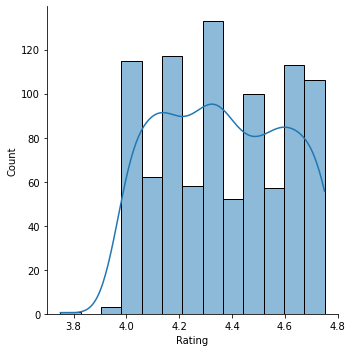

<Axes: xlabel='Rating'>

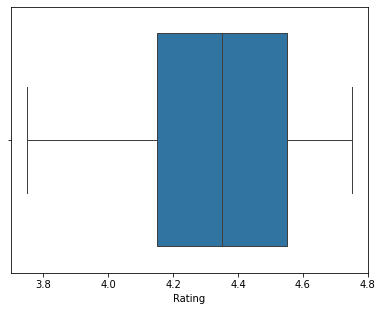

In [13]:
print(df['Rating'].describe())
print("skewness: ", df['Rating'].skew().round(4)) # type: ignore
sns.displot(kind='hist', kde=True, data=df,x='Rating')
plt.show()
sns.boxplot(data=df, x='Rating')

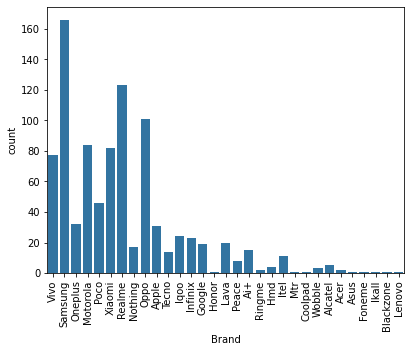

In [14]:
df['Brand'].value_counts()
# df['Brand'].value_counts().head(10).plot(kind='pie', autopct='%0.1f%%')
# plt.show()
sns.countplot(x=df['Brand'])
plt.xticks(rotation='vertical')
plt.show()

In [15]:
pd.concat([df['Brand'].value_counts(), df['Brand'].value_counts(normalize=True).mul(100).round(1)],
          axis=1, keys=['phones', 'percent']).head(10)

,phones,percent
Brand,,
Samsung,166,18.1
Realme,123,13.4
Oppo,101,11.0
Motorola,84,9.2
Xiaomi,82,8.9
Vivo,77,8.4
Poco,46,5.0
Oneplus,32,3.5
Apple,31,3.4


`df['SIM']` on its own prints the whole column, so it is left commented. `value_counts` below tells the same thing.

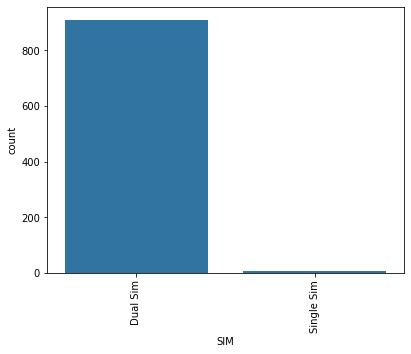

In [16]:
df['SIM'].value_counts()
# df['SIM'].value_counts().head(10).plot(kind='pie', autopct='%0.1f%%')
# plt.show()
sns.countplot(x=df['SIM'])
plt.xticks(rotation='vertical')
plt.show()

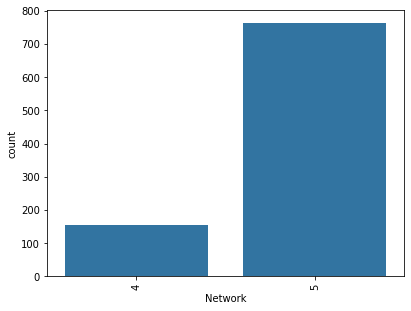

In [17]:
df['Network'].value_counts()
# df['Network'].value_counts().head(10).plot(kind='pie', autopct='%0.1f%%')
# plt.show()
sns.countplot(x=df['Network'])
plt.xticks(rotation='vertical')
plt.show()

<Axes: xlabel='NFC', ylabel='Price'>

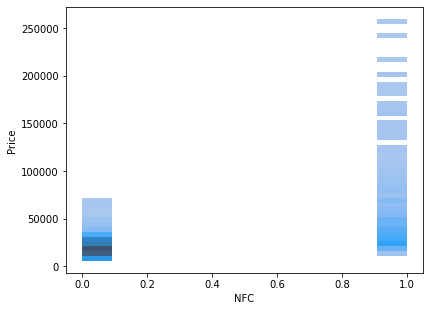

In [18]:
x = df['NFC'].fillna(0)
sns.histplot(x=x, y=df['Price'])

<Axes: xlabel='eSIM', ylabel='Price'>

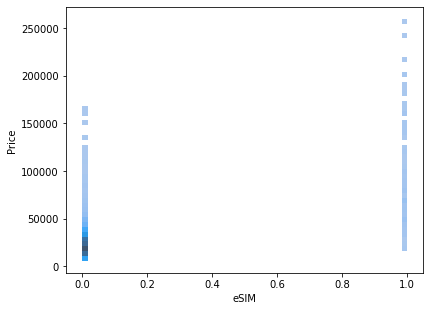

In [19]:
x = df['eSIM'].fillna(0)
sns.histplot(x=x, y=df['Price'])

<Axes: xlabel='IR_Blaster', ylabel='Price'>

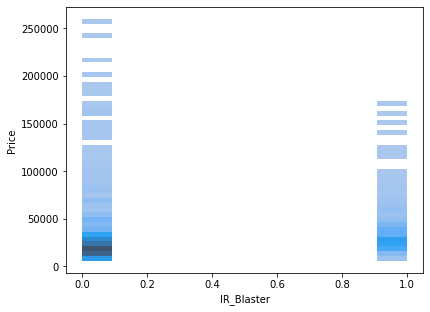

In [20]:
x = df['IR_Blaster'].fillna(0)
sns.histplot(x=x, y=df['Price'])

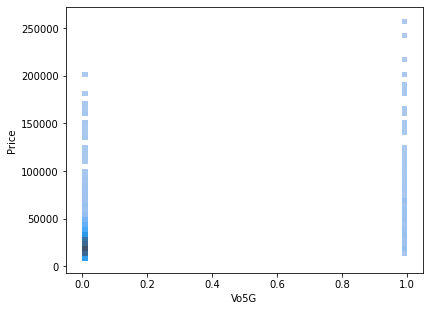

In [21]:
x = df['Vo5G'].fillna(0)
sns.histplot(x=x, y=df['Price'])
plt.show()

<b> NOTE :</b> Some of the processor_brand does not have naming based on their chipset family series most probably because of unpopularity of their chipset family 

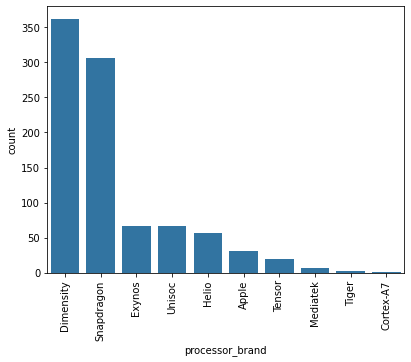

processor_brand
Dimensity     362
Snapdragon    306
Exynos         67
Unisoc         67
Helio          56
Apple          31
Tensor         19
Mediatek        6
Tiger           2
Cortex-A7       1
Name: count, dtype: int64

In [22]:
df['processor_brand'].value_counts()
sns.countplot(data=df, x='processor_brand', order=df['processor_brand'].value_counts().index)
plt.xticks(rotation='vertical')
plt.show()
df['processor_brand'].value_counts()

<Axes: xlabel='processor_cores', ylabel='count'>

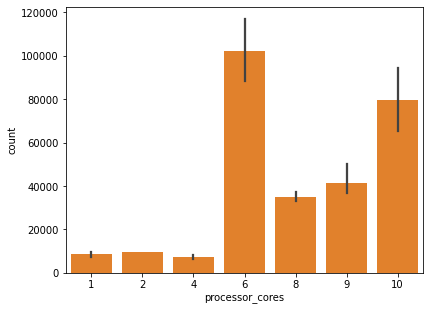

In [23]:
df['processor_cores'].value_counts()
sns.countplot(data=df, x='processor_cores')
sns.barplot(data=df, x='processor_cores', y='Price')

the uprising in prices for the phones having processor_cores == 6 is because of apple. Apple often use 6 cores processors

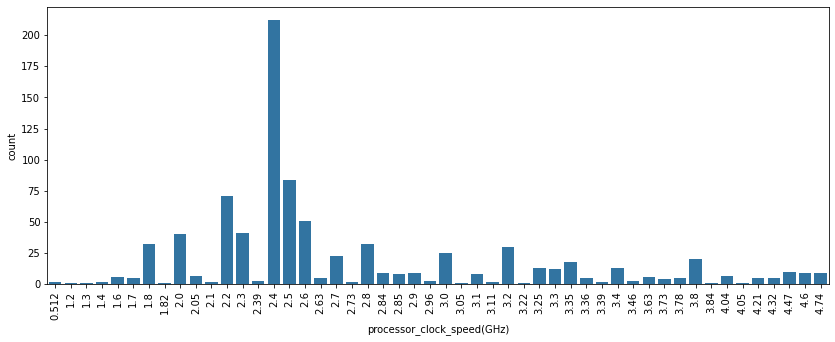

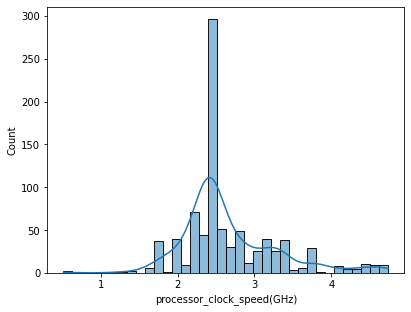

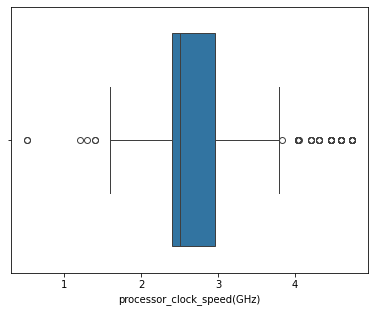

1.1361383219971664


count        46.000000
mean     113383.282609
std       55253.843256
min       51999.000000
25%       72249.000000
50%       86949.500000
75%      156999.000000
max      259999.000000
Name: Price, dtype: float64

In [24]:
df['processor_clock_speed(GHz)'].value_counts()

plt.figure(figsize=(14, 5))
sns.countplot(data=df, x='processor_clock_speed(GHz)')
plt.xticks(rotation='vertical')
plt.show()

sns.histplot(data=df, x='processor_clock_speed(GHz)', kde=True)
plt.show()

sns.boxplot(data=df, x='processor_clock_speed(GHz)')
plt.show()
print(df['processor_clock_speed(GHz)'].skew())

df['processor_clock_speed(GHz)'].describe()

df[df['processor_clock_speed(GHz)'] > 4]['Price'].describe()

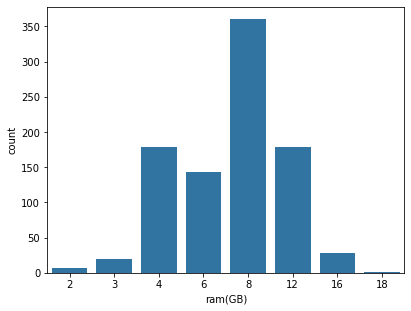

<Axes: xlabel='ram(GB)', ylabel='Price'>

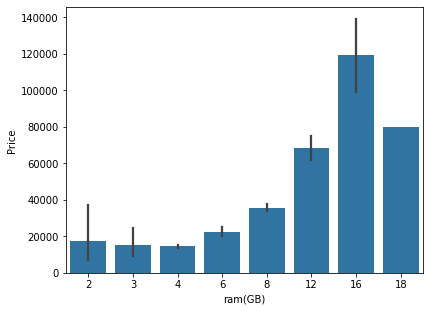

In [25]:
df['ram(GB)'].value_counts()
sns.countplot(data=df, x='ram(GB)')
plt.show()
# df['ram(GB)'].value_counts().head(7).plot(kind='pie', autopct='%0.1f%%')
# plt.show()

# df.select_dtypes(['float', 'int']).corr()['Price'].loc['ram(GB)']
sns.barplot(data=df, x='ram(GB)', y='Price')

**Insight :** 2 gb ram phones have price greater than of 4 is because of apple iphone 8 plus that cost around 77k so it shifted mean and as a result 2gb ram phones seems to have higher pricer than of 2gb ram phones, same case with 16gb ram phones can be explained, it's because so many foldable phones gives 16gb ram that costs more than 2 lakhs, on the other hand there is only one phone(oppo find x9 ultra) that offers 18gb ram with price around ~ 80K 

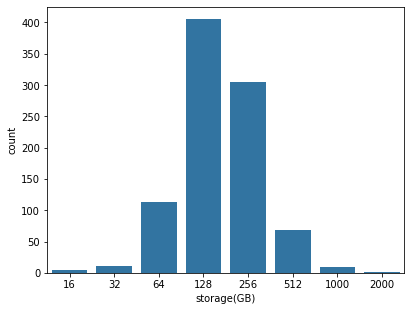

0.7230788627518859


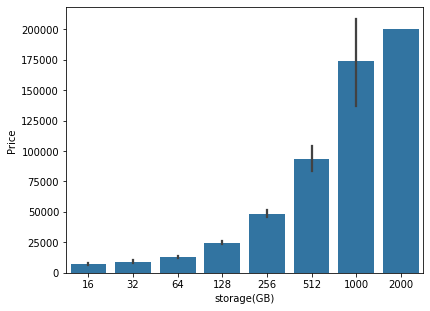

,Name,Specs,Price,Rating,Brand,SIM,Network,Vo5G,NFC,eSIM,...,display_design,isFoldable,isDualDisplay,rear_main_camera,rear_camera_count,front_main_camera,front_camera_count,card_supported,card_type,card_capacity(GB)
433,Apple iPhone 17 Pro Max,84,199900,4.0,Apple,Dual Sim,5,NaN,1.0,1.0,...,Dynamic Island,NaN,NaN,48.0,3,18.0,1,0.0,NaN,NaN


In [26]:
df['storage(GB)'].value_counts()
sns.countplot(data=df, x='storage(GB)')
plt.show()
# df['storage(GB)'].value_counts().head(7).plot(kind='pie', autopct='%0.1f%%')
# plt.show()

print(df['Price'].corr(df['storage(GB)']))
sns.barplot(data=df, x='storage(GB)', y='Price')
plt.show()
df[df['storage(GB)'] == 2000]

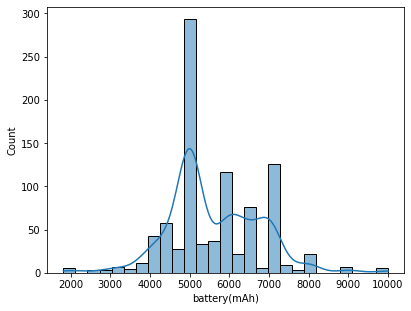

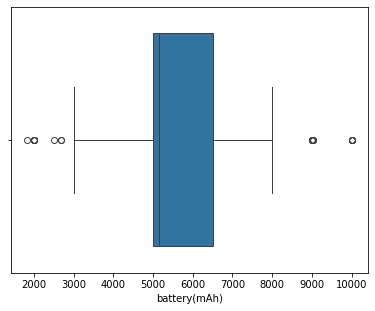

,Name,Specs,Price,Rating,Brand,SIM,Network,Vo5G,NFC,eSIM,...,display_design,isFoldable,isDualDisplay,rear_main_camera,rear_camera_count,front_main_camera,front_camera_count,card_supported,card_type,card_capacity(GB)
25,OnePlus Nord 6,85,44499,4.60,Oneplus,Dual Sim,5,NaN,1.0,NaN,...,Punch Hole,NaN,NaN,50.0,2,32.0,1,0.0,NaN,NaN
46,Realme P4 Power 5G,72,27999,4.75,Realme,Dual Sim,5,NaN,NaN,NaN,...,Punch Hole,NaN,NaN,50.0,2,16.0,1,0.0,NaN,NaN
69,Vivo T5 Pro,72,35975,4.00,Vivo,Dual Sim,5,1.0,NaN,NaN,...,Punch Hole,NaN,NaN,50.0,2,32.0,1,0.0,NaN,NaN
93,OnePlus Nord 6 5G,86,50499,4.25,Oneplus,Dual Sim,5,NaN,1.0,NaN,...,Punch Hole,NaN,NaN,50.0,2,32.0,1,0.0,NaN,NaN
149,Realme P4 Power 5G,74,29999,4.00,Realme,Dual Sim,5,NaN,NaN,NaN,...,Punch Hole,NaN,NaN,50.0,2,16.0,1,0.0,NaN,NaN
188,Vivo T5 Pro 5G,76,39999,4.30,Vivo,Dual Sim,5,1.0,NaN,NaN,...,Punch Hole,NaN,NaN,50.0,2,32.0,1,0.0,NaN,NaN
205,Poco X8 Pro Max,83,45999,4.05,Poco,Dual Sim,5,NaN,NaN,NaN,...,Punch Hole,NaN,NaN,50.0,2,20.0,1,NaN,NaN,NaN
259,Vivo T5 Pro 5G,74,39999,4.25,Vivo,Dual Sim,5,1.0,NaN,NaN,...,Punch Hole,NaN,NaN,50.0,2,32.0,1,0.0,NaN,NaN
282,Realme Narzo Power 5G,75,29998,4.50,Realme,Dual Sim,5,NaN,NaN,NaN,...,Punch Hole,NaN,NaN,50.0,2,16.0,1,0.0,NaN,NaN
319,Poco X8 Pro Max 5G,84,49999,4.05,Poco,Dual Sim,5,NaN,NaN,NaN,...,Punch Hole,NaN,NaN,50.0,2,20.0,1,NaN,NaN,NaN


In [27]:
df['battery(mAh)'].value_counts()
df['battery(mAh)'].describe()
sns.histplot(data=df, x='battery(mAh)', kde=True)
plt.show()
sns.boxplot(data=df, x='battery(mAh)')
plt.show()
df[df['battery(mAh)'] > 8000]

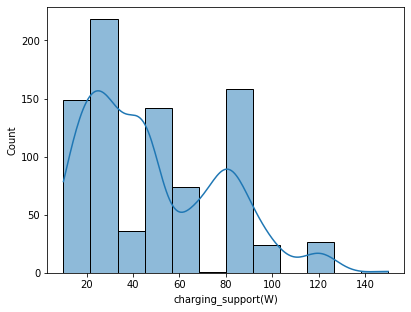

0.7315101825604844


count        831.0
mean     48.750903
std       28.93448
min           10.0
25%           25.0
50%           45.0
75%           80.0
max          150.0
Name: charging_support(W), dtype: Float64

In [28]:
sns.histplot(data=df, x='charging_support(W)', kde=True)
plt.show()
print(df['charging_support(W)'].skew())
df['charging_support(W)'].value_counts().sort_index()
df['charging_support(W)'].describe()
# plt.figure(figsize=(14, 6))

display_size median: 6.7 	display_size mode- 6.7
count    917.000000
mean       6.668255
std        0.342270
min        3.750000
25%        6.590000
50%        6.700000
75%        6.780000
max        8.090000
Name: display_size, dtype: float64


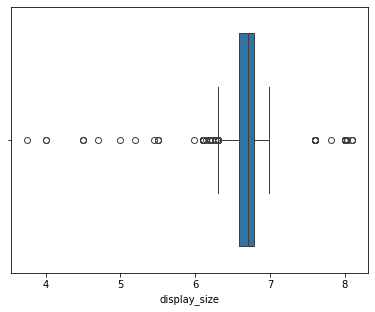

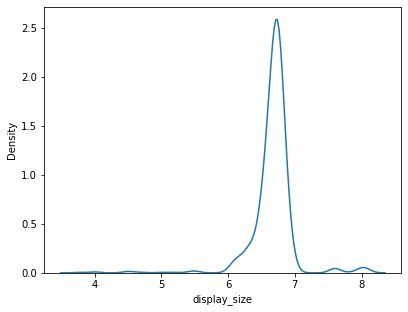

-2.2438371697783723


In [29]:
print("display_size median:", df['display_size'].median(), "\tdisplay_size mode-", df['display_size'].mode()[0])
print(df['display_size'].describe())
sns.boxplot(data=df, x='display_size')
plt.show()
df[df['display_size'] == df['display_size'].min()]
sns.kdeplot(data=df, x='display_size')
plt.show()
print(df['display_size'].skew())

In [30]:
# display_resolution will be considered later 

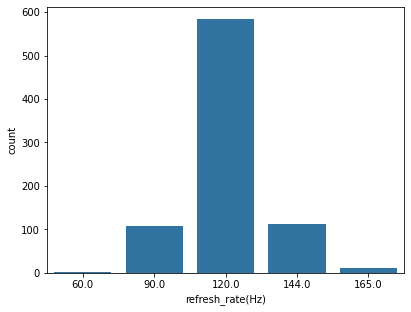

In [31]:
df['refresh_rate(Hz)'].value_counts().sum()
sns.countplot(data=df, x='refresh_rate(Hz)')
plt.show()

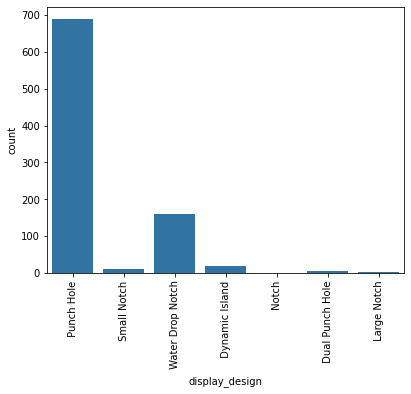

In [32]:
df['display_design'].value_counts()
df[df['display_design'].isna()][['Name', 'display_design', 'Price']]
sns.countplot(data=df, x='display_design')
plt.xticks(rotation='vertical')
plt.show()

In [33]:
print(df['isFoldable'].value_counts())
print(df['isDualDisplay'].value_counts())

isFoldable
1.0    38
Name: count, dtype: int64
isDualDisplay
1.0    42
Name: count, dtype: int64


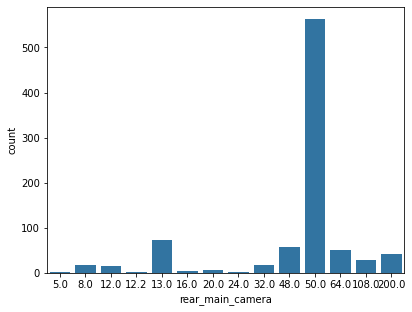

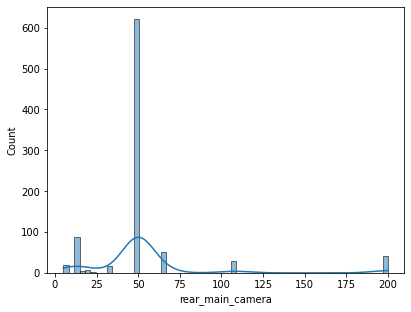

<Axes: xlabel='rear_main_camera'>

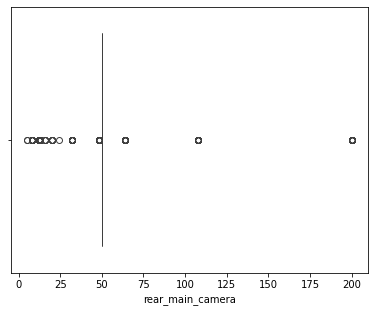

In [34]:
df['rear_main_camera'].value_counts().sum() 
sns.countplot(data=df, x='rear_main_camera')
plt.show()
# df['rear_main_camera'].value_counts().head(10).plot(kind='pie', autopct='%0.1f%%')
# plt.show()

df['rear_main_camera'].describe()
sns.histplot(data=df, x='rear_main_camera', kde=True)
plt.show()
sns.boxplot(data=df, x='rear_main_camera')

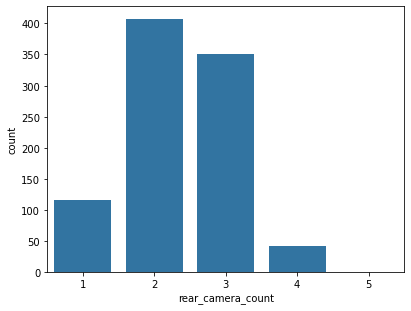

In [35]:
df['rear_camera_count'].value_counts()
sns.countplot(data=df, x='rear_camera_count')
plt.show()
# df['rear_camera_count'].value_counts().plot(kind='pie', autopct='%0.1f%%')

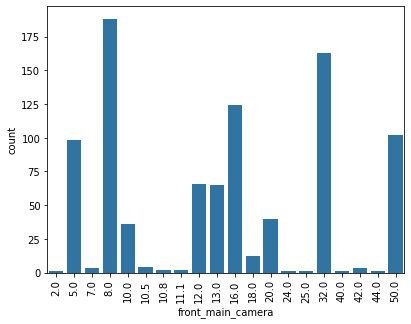

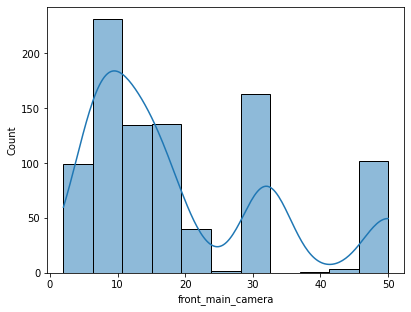

<Axes: >

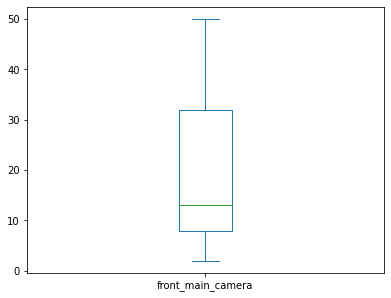

In [36]:
df['front_main_camera'].value_counts().sum() 
sns.countplot(data=df, x='front_main_camera')
plt.xticks(rotation='vertical')
plt.show()
# df['front_main_camera'].value_counts().head(10).plot(kind='pie', autopct='%0.1f%%')
# plt.show()

df['front_main_camera'].describe()
sns.histplot(data=df, x='front_main_camera', kde=True)
plt.show()
df['front_main_camera'].plot(kind='box')

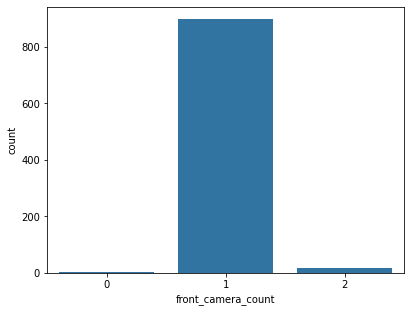

In [37]:
df['front_camera_count'].value_counts()
sns.countplot(data=df, x='front_camera_count')
plt.show()
# df['front_camera_count'].value_counts().plot(kind='pie', autopct='%0.1f%%')

<Axes: xlabel='card_supported', ylabel='count'>

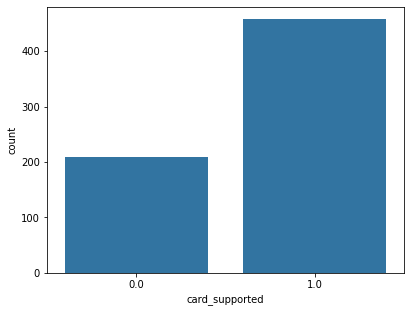

In [38]:
df['card_supported'].value_counts()
sns.countplot(data=df, x='card_supported')

<Axes: xlabel='card_type', ylabel='count'>

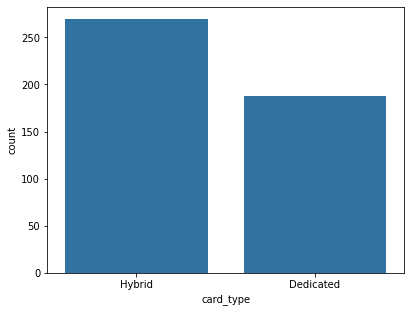

In [39]:
df['card_type'].value_counts()
sns.countplot(data=df, x='card_type')

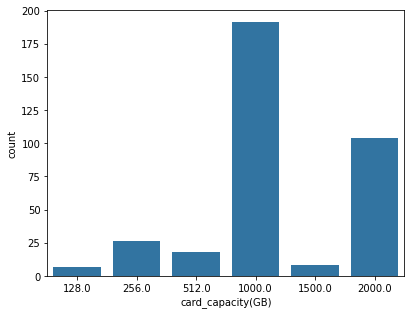

In [40]:
df['card_capacity(GB)'].value_counts()
sns.countplot(data=df, x='card_capacity(GB)')
plt.show()
# df['card_capacity(GB)'].value_counts().plot(kind='pie', autopct='%0.1f%%')

## BIVARIATE ANALYSIS

In [41]:
# name can't be of any help so we'll ignore that also in real world specs are not given they are derived parameters so that will also not be considered, same goes for rating column

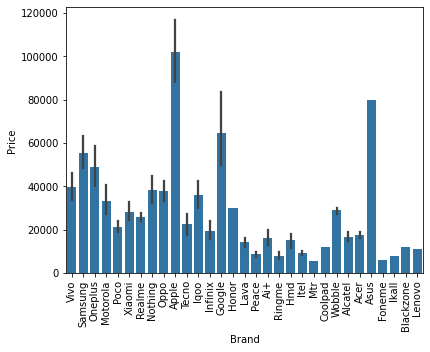

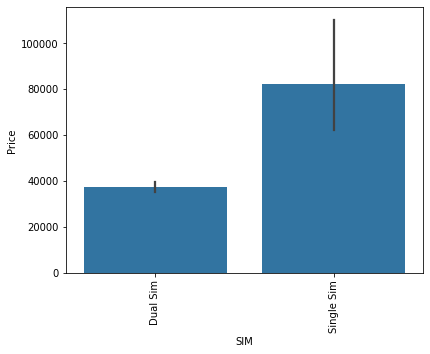

,Name,Specs,Price,Rating,Brand,SIM,Network,Vo5G,NFC,eSIM,...,display_design,isFoldable,isDualDisplay,rear_main_camera,rear_camera_count,front_main_camera,front_camera_count,card_supported,card_type,card_capacity(GB)
706,Samsung Galaxy Z Flip 5,76,62999,4.00,Samsung,Single Sim,5,1.0,1.0,NaN,...,Punch Hole,1.0,1.0,<NA>,2,10.0,1,0.0,NaN,NaN
758,Apple iPhone 8 Plus,48,49900,4.30,Apple,Single Sim,4,NaN,1.0,NaN,...,NaN,NaN,NaN,12.0,2,7.0,1,0.0,NaN,NaN
813,Samsung Galaxy Z Flip 5,77,68999,4.05,Samsung,Single Sim,5,1.0,1.0,NaN,...,Punch Hole,1.0,1.0,<NA>,2,10.0,1,0.0,NaN,NaN
900,Motorola Razr 2019,55,149999,4.25,Motorola,Single Sim,4,NaN,1.0,1.0,...,Large Notch,NaN,1.0,16.0,1,5.0,1,0.0,NaN,NaN
915,Apple iPhone 8 Plus,52,84900,4.10,Apple,Single Sim,4,NaN,1.0,NaN,...,NaN,NaN,NaN,12.0,2,7.0,1,0.0,NaN,NaN
916,Apple iPhone 8,48,77000,4.05,Apple,Single Sim,4,NaN,1.0,NaN,...,NaN,NaN,NaN,12.0,1,7.0,1,0.0,NaN,NaN


In [42]:
sns.barplot(data=df, x='Brand', y='Price')
plt.xticks(rotation='vertical')
plt.show()

sns.barplot(data=df, x='SIM', y='Price')
plt.xticks(rotation='vertical')
plt.show()

df[df['SIM'] == 'Single Sim']

**NOTE:**  single sim smartphones are offered by either apple or foldable premium phones. that's why thier is much difference between mean of dual sim smartphones and sigle sim smartphones 

In [43]:
brand_price = df.groupby('Brand')['Price'].agg(['count', 'mean', 'median', 'max'])
brand_price[brand_price['count'] >= 10].sort_values('median', ascending=False).round(0)

,count,mean,median,max
Brand,,,,
Apple,31,102179.0,87900.0,199900
Google,19,64798.0,49999.0,158999
Oneplus,32,48721.0,47249.0,149999
Samsung,166,55394.0,35749.0,259999
Nothing,17,38126.0,35320.0,79999
Oppo,101,37649.0,31990.0,169999
Iqoo,24,35918.0,31799.0,76998
Vivo,77,39550.0,28999.0,159999
Xiaomi,82,28023.0,24652.0,139998


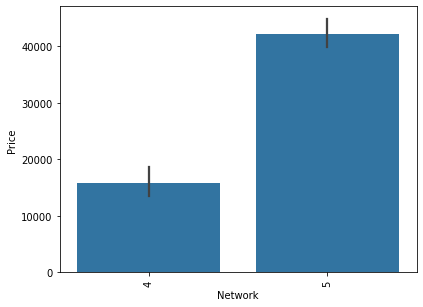

In [44]:
sns.barplot(data=df, x='Network', y='Price')
plt.xticks(rotation='vertical')
plt.show()

**Insight :** as we all know 5g phones most usually costlier than 4g but do you know ? only 5G label does not make a smartphone completely 5g because while calling 5G may switch to 4G lines resulting in lower internet and connection speed but if your smartphone have Vo5G feature than it shall continue to 5G lines.

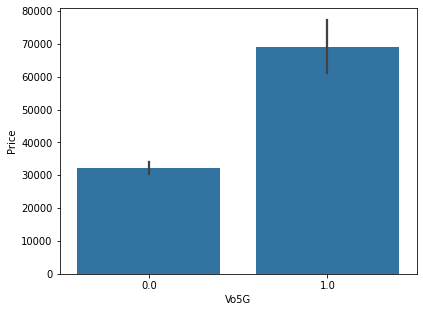

In [45]:
x = df['Vo5G'].fillna(0)
sns.barplot(x=x, y=df['Price'])
plt.show()

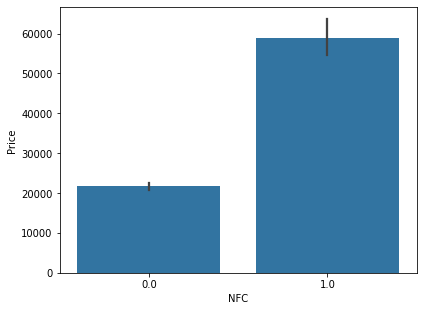

In [46]:
x = df['NFC'].fillna(0)
sns.barplot(x=x, y=df['Price'])
plt.show()

<b> NOTE : </b> for those who don't know NFC feature - NFC (Near Field Communication) is a short-range wireless technology that allows smartphones to exchange data with other devices or tags when held within 4 centimeters (about 1.5 inches) of each other.  It operates using electromagnetic induction, enabling powered devices (like phones) to communicate with passive tags or readers without needing a battery in the target device.

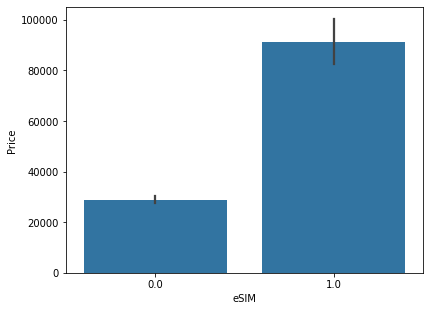

In [47]:
x = df['eSIM'].fillna(0)
sns.barplot(x=x, y=df['Price'])
plt.show()
# df[df['NFC'] == 1]

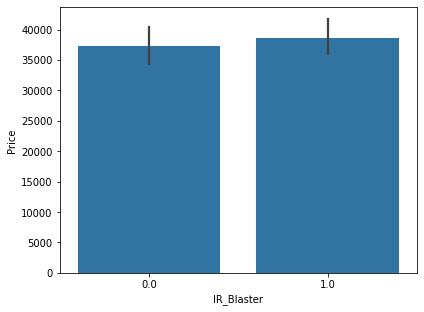

In [48]:
x = df['IR_Blaster'].fillna(0)
sns.barplot(x=x, y=df['Price'])
plt.show()

<b> NOTE: </b> IR_Blaster -- An IR blaster is a hardware component embedded in certain smartphones that emits invisible infrared signals to control electronic devices, effectively turning the phone into a universal remote.  It works by transmitting specific infrared light pulses that mimic traditional remote controls, allowing users to operate TVs, air conditioners, DVD players, and set-top boxes without needing Wi-Fi, Bluetooth pairing, or an internet connection

Some of the processor_brand does not have naming based on their chipset family series most probably because of unpopularity of their chipset family

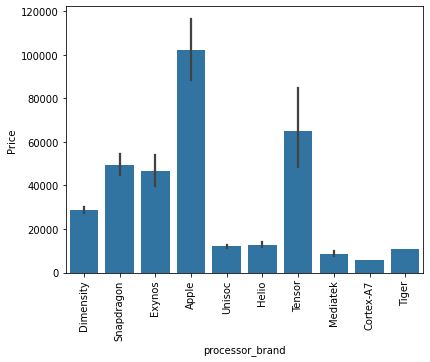

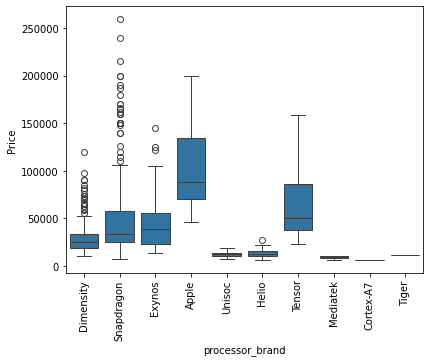

In [49]:
# sns.scatterplot(data=df, x='processor_brand', y='Price')
# plt.xticks(rotation='vertical')
# plt.show()

sns.barplot(data=df, x='processor_brand', y='Price')
plt.xticks(rotation='vertical')
plt.show()

sns.boxplot(data=df, x='processor_brand', y='Price')
plt.xticks(rotation='vertical')
plt.show()

In [50]:
df.groupby('processor_brand').agg(phones=('Price', 'size'),
                                  median_price=('Price', 'median'),
                                  avg_clock=('processor_clock_speed(GHz)', 'mean')).round(2).sort_values('median_price', ascending=False)

,phones,median_price,avg_clock
processor_brand,,,
Apple,31,87900.0,3.53
Tensor,19,49999.0,3.14
Exynos,67,38789.0,2.77
Snapdragon,306,33999.0,2.87
Dimensity,362,24999.0,2.64
Unisoc,67,11999.0,1.93
Helio,56,11999.0,2.05
Tiger,2,10999.0,1.80
Mediatek,6,8999.0,1.48


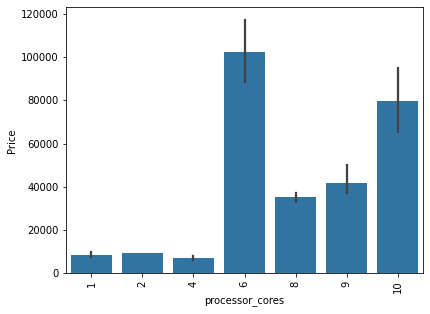

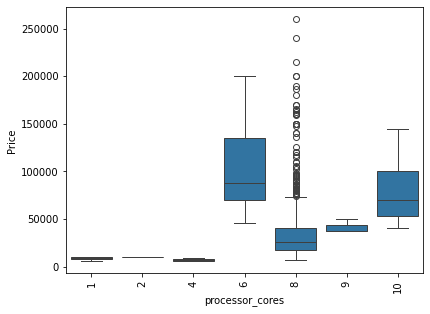

,Name,Price,ram(GB),storage(GB),processor_brand,processor_cores
227,Peace I17 Pro,8499,6,128,Helio,4
274,Ringme Bold 17 Mini,6299,3,32,Helio,4
371,Peace i17 Air,8499,4,128,Mediatek,1
501,Peace Honor 20,5800,4,64,Helio,1
584,MTR M16 Pro,5700,3,32,Cortex-A7,4
624,Ringme Bold 17 Pro,9499,4,64,Mediatek,2
634,Peace Nova 17 Pro 4G,10500,6,64,Mediatek,1
763,Peace Honor 10,8999,4,64,Helio,1
770,Foneme F17 Pro,5900,2,16,Mediatek,4
772,Peace Nova 17 Pro 4G,9999,4,64,Mediatek,1


In [51]:
# sns.scatterplot(data=df, x='processor_cores', y='Price')
# plt.xticks(rotation='vertical')
# plt.show()

sns.barplot(data=df, x='processor_cores', y='Price')
plt.xticks(rotation='vertical')
plt.show()

sns.boxplot(data=df, x='processor_cores', y='Price')
plt.xticks(rotation='vertical')
plt.show()

df[df['processor_cores'] < 6][['Name', 'Price', 'ram(GB)', 'storage(GB)', 'processor_brand', 'processor_cores']]

In [52]:
df[df['processor_cores'] == 6]['Brand'].value_counts()

Brand
Apple    31
Name: count, dtype: int64

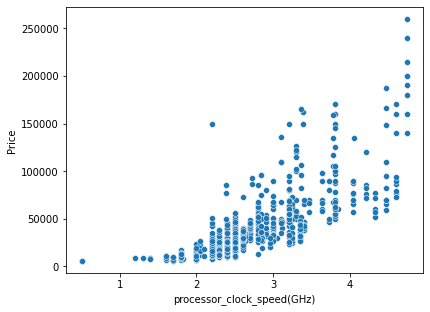

0.7783853047978354


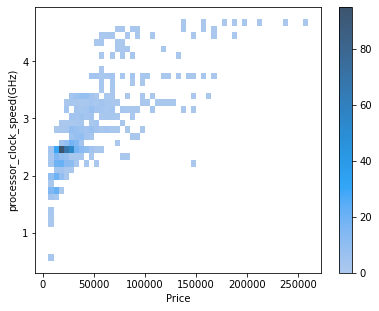

In [53]:
sns.scatterplot(data=df, x='processor_clock_speed(GHz)', y='Price')
plt.show()

print(df['Price'].corr(df['processor_clock_speed(GHz)']))

sns.histplot(data=df,x='Price', y='processor_clock_speed(GHz)', cbar=True)
plt.show()

# sns.kdeplot(data=df,x='Price', y='processor_clock_speed(GHz)', cbar=True)
# plt.show()

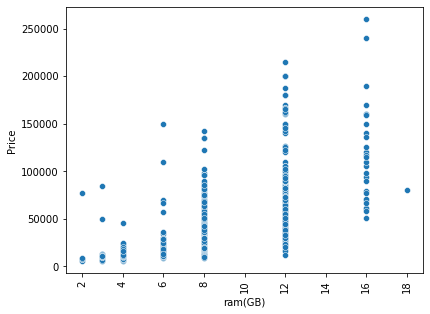

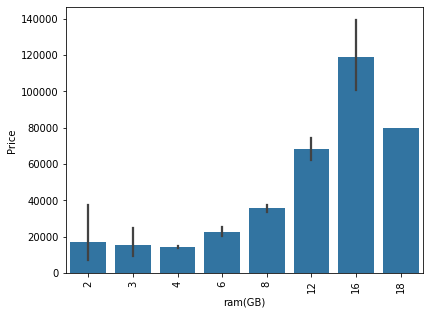

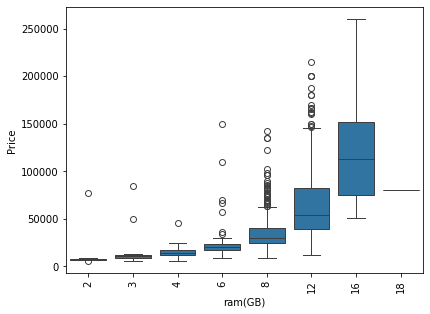

,Name,Price,ram(GB)
487,Realme C2,6999,2
546,itel Zeno 100 Lite,7699,2
770,Foneme F17 Pro,5900,2
907,Xiaomi Redmi 7A,7449,2
914,Xiaomi Redmi 5A,7499,2
916,Apple iPhone 8,77000,2
918,Samsung Galaxy On7 Pro,8490,2


,Name,Price,ram(GB)
156,Vivo X300 Ultra,159999,16
214,OnePlus 15 5G,93998,16
233,Vivo X300 Pro 5G,119999,16
290,Google Pixel 10 Pro XL,116830,16
315,Samsung Galaxy Z Fold 8 Ultra,259999,16
320,Xiaomi 17 Ultra,139998,16
382,Samsung Galaxy S26 Ultra,189999,16
468,Google Pixel 10 Pro,104990,16
589,Vivo X Fold 5 5G,125990,16
595,Google Pixel 9 Pro,109999,16


In [54]:
sns.scatterplot(data=df, x='ram(GB)', y='Price')
plt.xticks(rotation='vertical')
plt.show()

sns.barplot(data=df, x='ram(GB)', y='Price')
plt.xticks(rotation='vertical')
plt.show()

sns.boxplot(data=df, x='ram(GB)', y='Price')
plt.xticks(rotation='vertical')
plt.show()

x = df[df['ram(GB)'] == 2]
display(x[x['Price'] > df[df['ram(GB)'] == 4]['Price'].min()][['Name', 'Price', 'ram(GB)']])

x = df[(df['ram(GB)'] == 16)]
display(x[x['Price'] > df[df['ram(GB)'] == 18]['Price'].values[0]][['Name', 'Price', 'ram(GB)']])

In [55]:
pd.concat([df.groupby('ram(GB)')['Price'].mean(), df.groupby('ram(GB)')['Price'].median(), df['ram(GB)'].value_counts()],
          axis=1, keys=['mean', 'median', 'phones']).round(0)

,mean,median,phones
ram(GB),,,
2,17291.0,7499.0,7
3,15394.0,10434.0,20
4,14437.0,13999.0,179
6,22406.0,19999.0,143
8,35576.0,29999.0,360
12,68277.0,53499.0,179
16,119076.0,112424.0,28
18,79999.0,79999.0,1


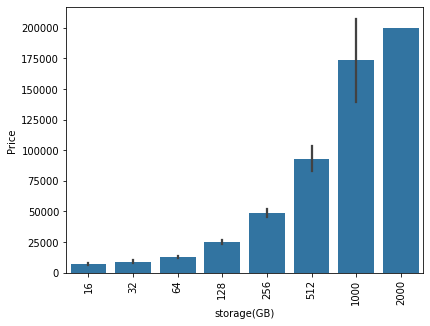

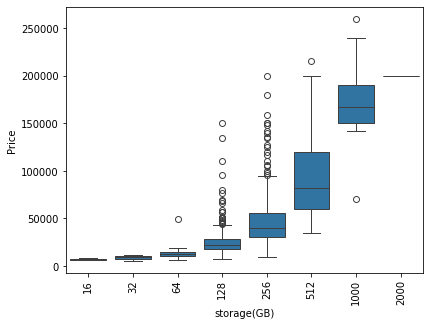

0.7230788627518859


In [56]:
# sns.scatterplot(data=df, x='storage(GB)', y='Price')
# plt.xticks(rotation='vertical')
# plt.show()

sns.barplot(data=df, x='storage(GB)', y='Price')
plt.xticks(rotation='vertical')
plt.show()

sns.boxplot(data=df, x='storage(GB)', y='Price')
plt.xticks(rotation='vertical')
plt.show()

print(df['Price'].corr(df['storage(GB)']))

In [57]:
pd.concat([df.groupby('storage(GB)')['Price'].mean(), df.groupby('storage(GB)')['Price'].median(), df['storage(GB)'].value_counts()],
          axis=1, keys=['mean', 'median', 'phones']).round(0)

,mean,median,phones
storage(GB),,,
16,7222.0,7249.0,4
32,9020.0,9793.0,11
64,12997.0,12479.0,113
128,24793.0,21939.0,405
256,48640.0,39990.0,305
512,93084.0,81990.0,69
1000,173854.0,166900.0,9
2000,199900.0,199900.0,1


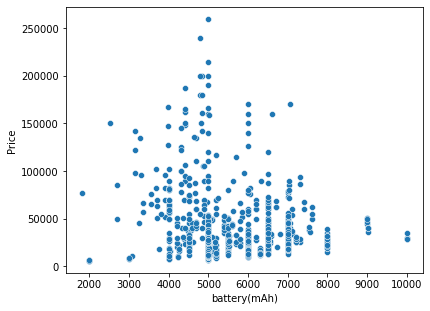

-0.139749690514576


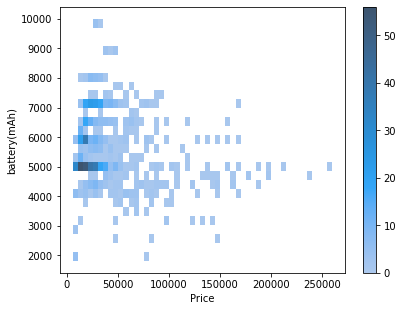

In [58]:
sns.scatterplot(data=df, x='battery(mAh)', y='Price')
plt.show()

print(df['Price'].corr(df['battery(mAh)']))

sns.histplot(data=df,x='Price', y='battery(mAh)', cbar=True)
plt.show()

# sns.kdeplot(data=df,x='Price', y='battery(mAh)', cbar=True)
# plt.show()

In [59]:
df.groupby(pd.qcut(df['Price'], 5))['battery(mAh)'].median()

C:\Users\Asus\AppData\Local\Temp\ipykernel_4396\2793814754.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['Price'], 5))['battery(mAh)'].median()


Price
(5699.999, 15999.0]    5000.0
(15999.0, 22999.0]     6000.0
(22999.0, 30999.0]     5800.0
(30999.0, 49999.0]     5800.0
(49999.0, 259999.0]    4900.0
Name: battery(mAh), dtype: Float64

In [60]:
df['battery(mAh)'].value_counts().sort_index().tail(10)

battery(mAh)
7200      8
7300      4
7400      2
7540      2
7550      1
7600      3
8000     22
9000      4
9020      3
10001     5
Name: count, dtype: Int64

**Insight :** battery has almost no link with price, instead it has slightly -ve correlation(~ -14) it's because the budget price phones provides more battery capacity as marketing parameter but premium phones still intact with mostly 5000-7000 mAh batteries 

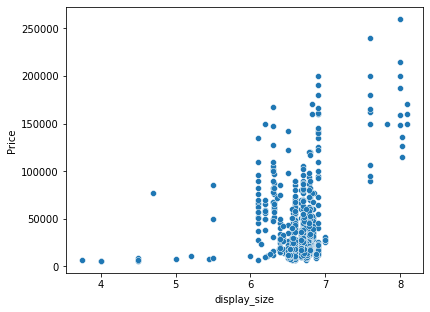

0.3049037214289627


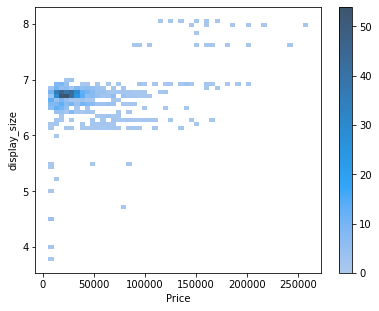

0.3049037214289627


In [61]:
sns.scatterplot(data=df, x='display_size', y='Price')
plt.show()

print(df['Price'].corr(df['display_size']))

sns.histplot(data=df,x='Price', y='display_size', cbar=True)
plt.show()

# sns.kdeplot(data=df,x='Price', y='display_size', cbar=True)
# plt.show()

print(df['Price'].corr(df['display_size']))

In [62]:
df.sort_values('display_size', ascending=False)[['Name', 'display_size', 'Price']].head(5)

,Name,display_size,Price
638,Motorola Razr Fold FIFA World Cup 26 Edition,8.09,169999
639,Motorola Razr Fold,8.09,159999
492,Motorola Razr Fold,8.09,149999
589,Vivo X Fold 5 5G,8.03,125990
688,Google Pixel 9 Pro Fold,8.03,135900


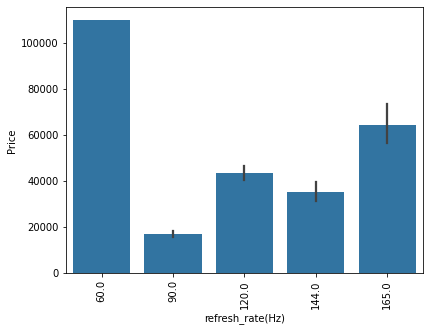

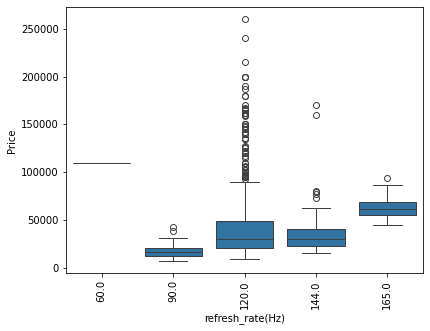

,Name,Specs,Price,Rating,Brand,SIM,Network,Vo5G,NFC,eSIM,...,display_design,isFoldable,isDualDisplay,rear_main_camera,rear_camera_count,front_main_camera,front_camera_count,card_supported,card_type,card_capacity(GB)
156,Vivo X300 Ultra,98,159999,4.5,Vivo,Dual Sim,5,NaN,1.0,NaN,...,Punch Hole,NaN,NaN,200.0,3,50.0,1,0.0,NaN,NaN
300,OPPO Find X9 Ultra,94,169999,4.0,Oppo,Dual Sim,5,NaN,1.0,1.0,...,Punch Hole,NaN,NaN,200.0,5,50.0,1,0.0,NaN,NaN


In [63]:
# # sns.scatterplot(data=df, x='refresh_rate(Hz)', y='Price')
# # plt.xticks(rotation='vertical')
# # plt.show()

sns.barplot(data=df, x='refresh_rate(Hz)', y='Price')
plt.xticks(rotation='vertical')
plt.show()

sns.boxplot(data=df, x='refresh_rate(Hz)', y='Price')
plt.xticks(rotation='vertical')
plt.show()

df[(df['refresh_rate(Hz)'] >= 60)  & (df['Brand'] == 'Apple')]
x = df[(df['refresh_rate(Hz)'] == 144)]
x[x['Price'] > df[df['refresh_rate(Hz)'] > 144]['Price'].max()]

In [64]:
df.groupby('refresh_rate(Hz)')['Price'].agg(['count', 'mean', 'median']).round(0)

,count,mean,median
refresh_rate(Hz),,,
60.0,1,109900.0,109900.0
90.0,108,16962.0,15999.0
120.0,583,43300.0,29999.0
144.0,113,35095.0,29999.0
165.0,11,64293.0,61499.0


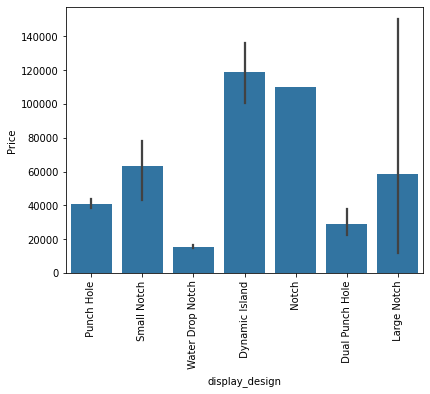

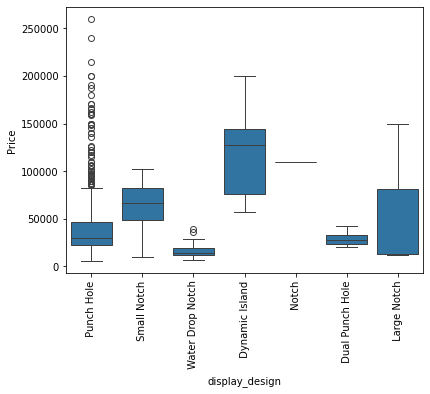

In [65]:
# sns.scatterplot(data=df, x='display_design', y='Price')
# plt.xticks(rotation='vertical')
# plt.show()

sns.barplot(data=df, x='display_design', y='Price')
plt.xticks(rotation='vertical')
plt.show()

sns.boxplot(data=df, x='display_design', y='Price')
plt.xticks(rotation='vertical')
plt.show()

# sns.violinplot(data=df, x='display_design', y='Price')
# plt.xticks(rotation='vertical')
# plt.show()

In [66]:
df.groupby('display_design')['Price'].agg(['count', 'median']).sort_values('median')

,count,median
display_design,,
Large Notch,3,12999.0
Water Drop Notch,160,14397.0
Dual Punch Hole,4,27244.5
Punch Hole,688,29999.0
Small Notch,10,66195.0
Notch,1,109900.0
Dynamic Island,19,126900.0


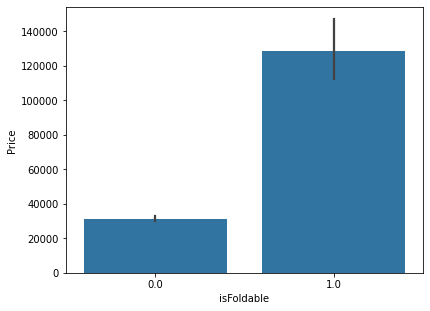

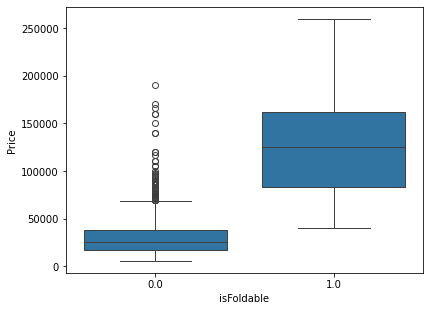

In [67]:
d = df[df['Brand'] != 'Apple']
x = d['isFoldable'].fillna(0)

sns.barplot(x=x, y=d['Price'])
plt.xticks()
plt.show()

sns.boxplot(x=x, y=d['Price'])
plt.xticks()
plt.show()

# sns.scatterplot(x=x, y=d['Price'])
# sns.violinplot(x=x, y=d['Price'])

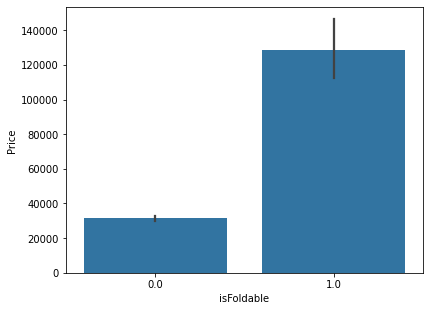

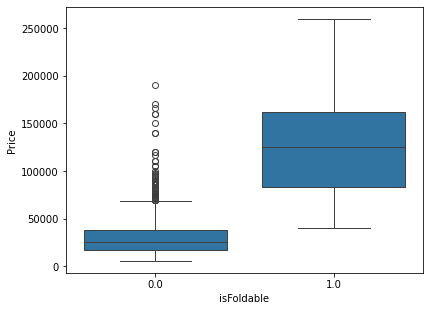

In [68]:
# x = df['isDualDisplay'].fillna(0)
# sns.scatterplot(x=x, y=df['Price'])
# plt.xticks()
# plt.show()

sns.barplot(x=x, y=df['Price'])
plt.xticks()
plt.show()

sns.boxplot(x=x, y=df['Price'])
plt.xticks()
plt.show()

# sns.violinplot(x=x, y=df['Price'])
# plt.xticks()
# plt.show()

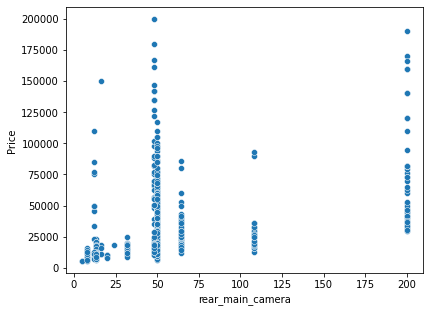

0.376760111756956


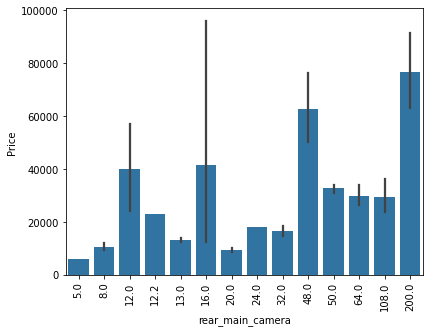

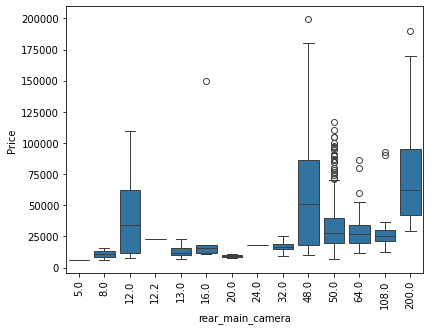

,Name,Specs,Price,Rating,Brand,SIM,Network,Vo5G,NFC,eSIM,...,display_design,isFoldable,isDualDisplay,rear_main_camera,rear_camera_count,front_main_camera,front_camera_count,card_supported,card_type,card_capacity(GB)
227,Peace I17 Pro,34,8499,4.50,Peace,Dual Sim,4,NaN,NaN,NaN,...,NaN,NaN,NaN,20.0,1,8.0,1,1.0,Dedicated,128.0
371,Peace i17 Air,32,8499,4.10,Peace,Dual Sim,4,NaN,NaN,NaN,...,NaN,NaN,NaN,20.0,1,8.0,1,1.0,Dedicated,128.0
538,Motorola Moto G04,45,10999,4.10,Motorola,Dual Sim,4,NaN,NaN,NaN,...,Punch Hole,NaN,NaN,16.0,1,5.0,1,1.0,Dedicated,1000.0
623,Vivo S1,48,17990,4.65,Vivo,Dual Sim,4,NaN,NaN,NaN,...,Water Drop Notch,NaN,NaN,16.0,3,32.0,1,1.0,Dedicated,256.0
634,Peace Nova 17 Pro 4G,34,10500,4.75,Peace,Dual Sim,4,NaN,NaN,NaN,...,NaN,NaN,NaN,20.0,1,8.0,1,1.0,Hybrid,128.0
772,Peace Nova 17 Pro 4G,32,9999,4.55,Peace,Dual Sim,4,NaN,NaN,NaN,...,NaN,NaN,NaN,20.0,1,8.0,1,1.0,Hybrid,128.0
774,Peace Nova 16 Pro 4G,34,9999,4.65,Peace,Dual Sim,4,NaN,NaN,NaN,...,NaN,NaN,NaN,20.0,1,8.0,1,1.0,Hybrid,128.0
775,iKall Z10 4G 2025,37,7999,4.00,Ikall,Dual Sim,4,NaN,NaN,NaN,...,NaN,NaN,NaN,20.0,1,8.0,1,1.0,Hybrid,NaN
829,Motorola Moto E22s,43,11499,4.70,Motorola,Dual Sim,4,NaN,NaN,NaN,...,Punch Hole,NaN,NaN,16.0,2,8.0,1,1.0,Dedicated,NaN
900,Motorola Razr 2019,55,149999,4.25,Motorola,Single Sim,4,NaN,1.0,1.0,...,Large Notch,NaN,1.0,16.0,1,5.0,1,0.0,NaN,NaN


In [69]:
sns.scatterplot(data=df, x='rear_main_camera', y='Price')
plt.show()

print(df['Price'].corr(df['rear_main_camera']))

sns.barplot(data=df, x='rear_main_camera', y='Price')
plt.xticks(rotation='vertical')
plt.show()

sns.boxplot(data=df, x='rear_main_camera', y='Price')
plt.xticks(rotation='vertical')
plt.show()

df[(df['rear_main_camera'] > 13) & (df['rear_main_camera'] < 24)]

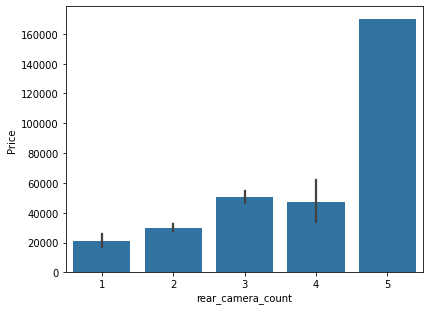

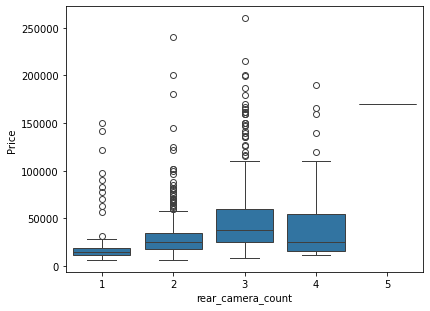

,Name,Specs,Price,Rating,Brand,SIM,Network,Vo5G,NFC,eSIM,...,display_design,isFoldable,isDualDisplay,rear_main_camera,rear_camera_count,front_main_camera,front_camera_count,card_supported,card_type,card_capacity(GB)
300,OPPO Find X9 Ultra,94,169999,4.0,Oppo,Dual Sim,5,NaN,1.0,1.0,...,Punch Hole,NaN,NaN,200.0,5,50.0,1,0.0,NaN,NaN


In [70]:
# sns.scatterplot(data=df, x='rear_camera_count', y=df['Price'])
# plt.xticks()
# plt.show()

sns.barplot(data=df, x='rear_camera_count', y=df['Price'])
plt.xticks()
plt.show()

sns.boxplot(data=df, x='rear_camera_count', y=df['Price'])
plt.xticks()
plt.show()

# sns.violinplot(data=df, x='rear_camera_count', y=df['Price'])
# plt.xticks()
# plt.show()

df[(df['rear_camera_count'] == 5)]

0.2093206693255288


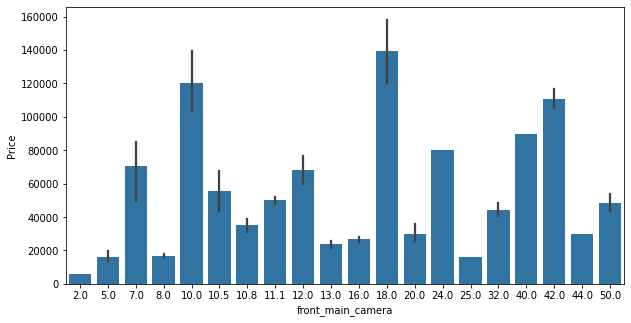

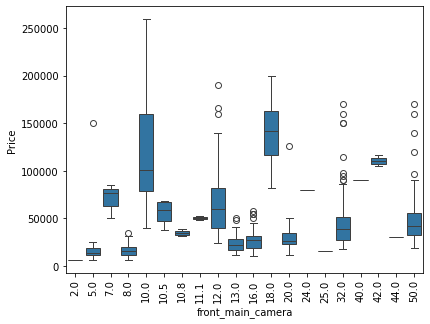

0.2093206693255288


In [71]:
# sns.scatterplot(data=df, x='front_main_camera', y='Price')
# plt.show()

print(df['Price'].corr(df['front_main_camera']))

plt.figure(figsize=(10, 5))
sns.barplot(data=df,x='front_main_camera', y='Price')
plt.show()

sns.boxplot(data=df,x='front_main_camera', y='Price')
plt.xticks(rotation='vertical')
plt.show()
print(df['Price'].corr(df['front_main_camera']))

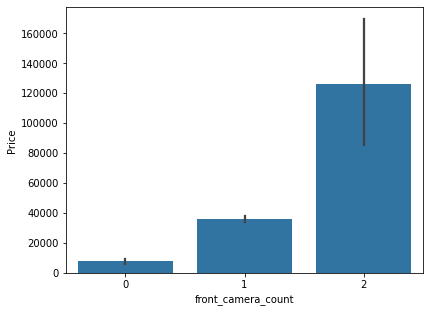

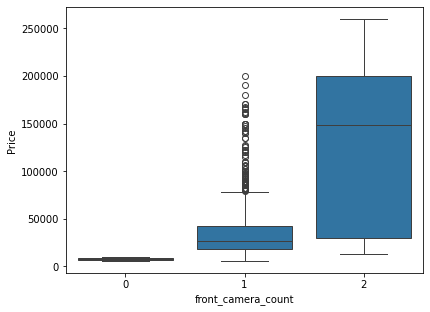

,Name,Specs,Price,Rating,Brand,SIM,Network,Vo5G,NFC,eSIM,...,display_design,isFoldable,isDualDisplay,rear_main_camera,rear_camera_count,front_main_camera,front_camera_count,card_supported,card_type,card_capacity(GB)
117,Samsung Galaxy Z Fold 8 Ultra,98,199999,4.35,Samsung,Dual Sim,5,1.0,1.0,1.0,...,Punch Hole,1.0,1.0,<NA>,3,10.0,2,NaN,NaN,NaN
199,Samsung Galaxy Z Fold 8 5G,93,179999,4.60,Samsung,Dual Sim,5,1.0,1.0,1.0,...,Punch Hole,1.0,1.0,<NA>,2,10.0,2,NaN,NaN,NaN
315,Samsung Galaxy Z Fold 8 Ultra,98,259999,4.35,Samsung,Dual Sim,5,1.0,1.0,1.0,...,Punch Hole,1.0,1.0,<NA>,3,10.0,2,NaN,NaN,NaN
548,Samsung Galaxy Z Fold 8 Ultra,95,214999,4.15,Samsung,Dual Sim,5,1.0,1.0,1.0,...,Punch Hole,1.0,1.0,<NA>,3,10.0,2,NaN,NaN,NaN
627,Samsung Galaxy Z Fold 8,94,239999,4.00,Samsung,Dual Sim,5,1.0,1.0,1.0,...,Punch Hole,1.0,1.0,<NA>,2,10.0,2,NaN,NaN,NaN
628,Samsung Galaxy Z Fold 8,93,199999,4.55,Samsung,Dual Sim,5,1.0,1.0,1.0,...,Punch Hole,1.0,1.0,<NA>,2,10.0,2,NaN,NaN,NaN
660,Google Pixel 10 Pro Fold,88,158999,4.00,Google,Dual Sim,5,NaN,1.0,1.0,...,Punch Hole,1.0,1.0,<NA>,3,10.0,2,NaN,NaN,NaN
666,Samsung Galaxy Z Fold 7,97,186999,4.75,Samsung,Dual Sim,5,1.0,1.0,1.0,...,Punch Hole,1.0,1.0,<NA>,3,10.0,2,NaN,NaN,NaN


In [72]:
# sns.scatterplot(data=df, x='front_camera_count', y=df['Price'])
# plt.xticks()
# plt.show()

sns.barplot(data=df, x='front_camera_count', y=df['Price'])
plt.xticks()
plt.show()

sns.boxplot(data=df, x='front_camera_count', y=df['Price'])
plt.xticks()
plt.show()

# sns.violinplot(data=df, x='front_camera_count', y=df['Price'])
# plt.xticks()
# plt.show()

x = df[(df['front_camera_count'] > 1)]
x[x['Price'] > 150000]

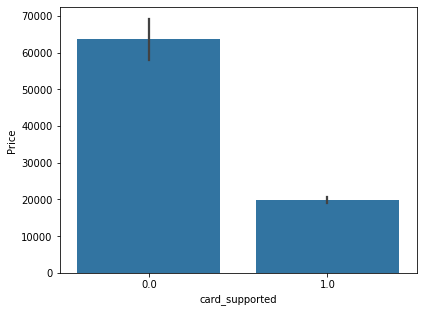

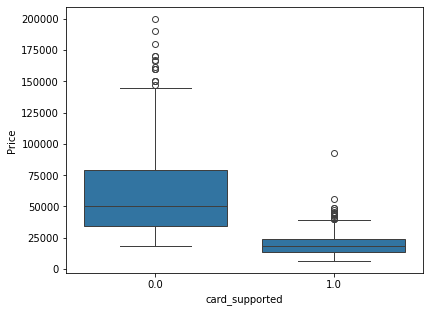

In [73]:
# sns.scatterplot(data=df, x='card_supported', y=df['Price'])
# plt.xticks()
# plt.show()

sns.barplot(data=df, x='card_supported', y=df['Price'])
plt.xticks()
plt.show()

sns.boxplot(data=df, x='card_supported', y=df['Price'])
plt.xticks()
plt.show()

# sns.violinplot(data=df, x='card_supported', y=df['Price'])
# plt.xticks()
# plt.show()

In [74]:
# groupby : price with and without a card slot
df.groupby('card_supported')['Price'].agg(['count', 'mean', 'median']).round(0)

,count,mean,median
card_supported,,,
0.0,209,63676.0,49999.0
1.0,457,19715.0,17999.0


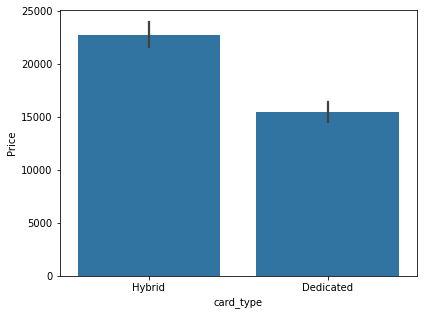

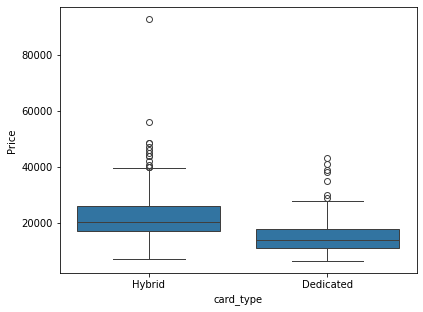

In [75]:
# sns.scatterplot(data=df, x='card_type', y=df['Price'])
# plt.xticks()
# plt.show()

sns.barplot(data=df, x='card_type', y=df['Price'])
plt.xticks()
plt.show()

sns.boxplot(data=df, x='card_type', y=df['Price'])
plt.xticks()
plt.show()

# sns.violinplot(data=df, x='card_type', y=df['Price'])
# plt.xticks()
# plt.show()

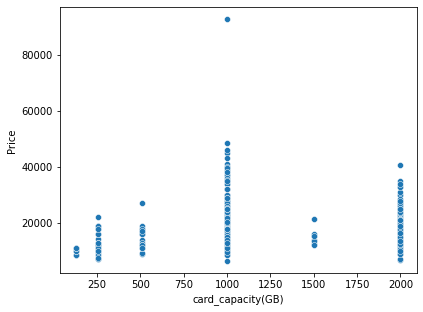

0.13516537740708667


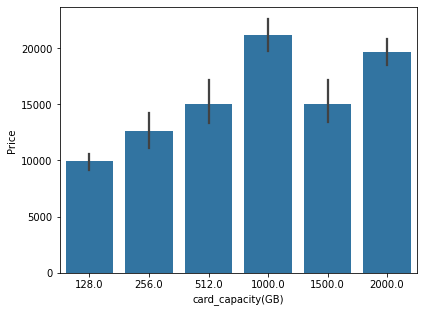

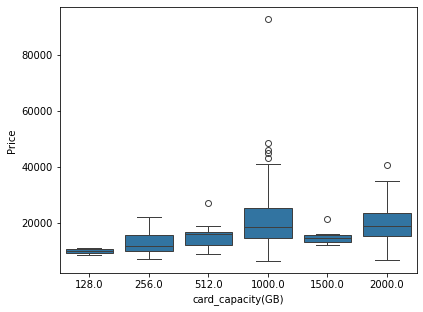

0.13516537740708667


,Name,Specs,Price,Rating,Brand,SIM,Network,Vo5G,NFC,eSIM,...,display_design,isFoldable,isDualDisplay,rear_main_camera,rear_camera_count,front_main_camera,front_camera_count,card_supported,card_type,card_capacity(GB)
756,Samsung Galaxy Note 20 Ultra 5G,75,92800,4.1,Samsung,Dual Sim,5,NaN,1.0,NaN,...,Punch Hole,NaN,NaN,108.0,3,10.0,1,1.0,Hybrid,1000.0


In [76]:
sns.scatterplot(data=df, x='card_capacity(GB)', y='Price')
plt.show()

print(df['Price'].corr(df['card_capacity(GB)']))

sns.barplot(data=df,y='Price', x='card_capacity(GB)')
plt.show()

sns.boxplot(data=df,y='Price', x='card_capacity(GB)')
plt.show()

print(df['Price'].corr(df['card_capacity(GB)']))
df[(df['card_capacity(GB)'] == 1000) & (df['Price'] > 90000)]

## MULTIVARIATE ANALYSIS

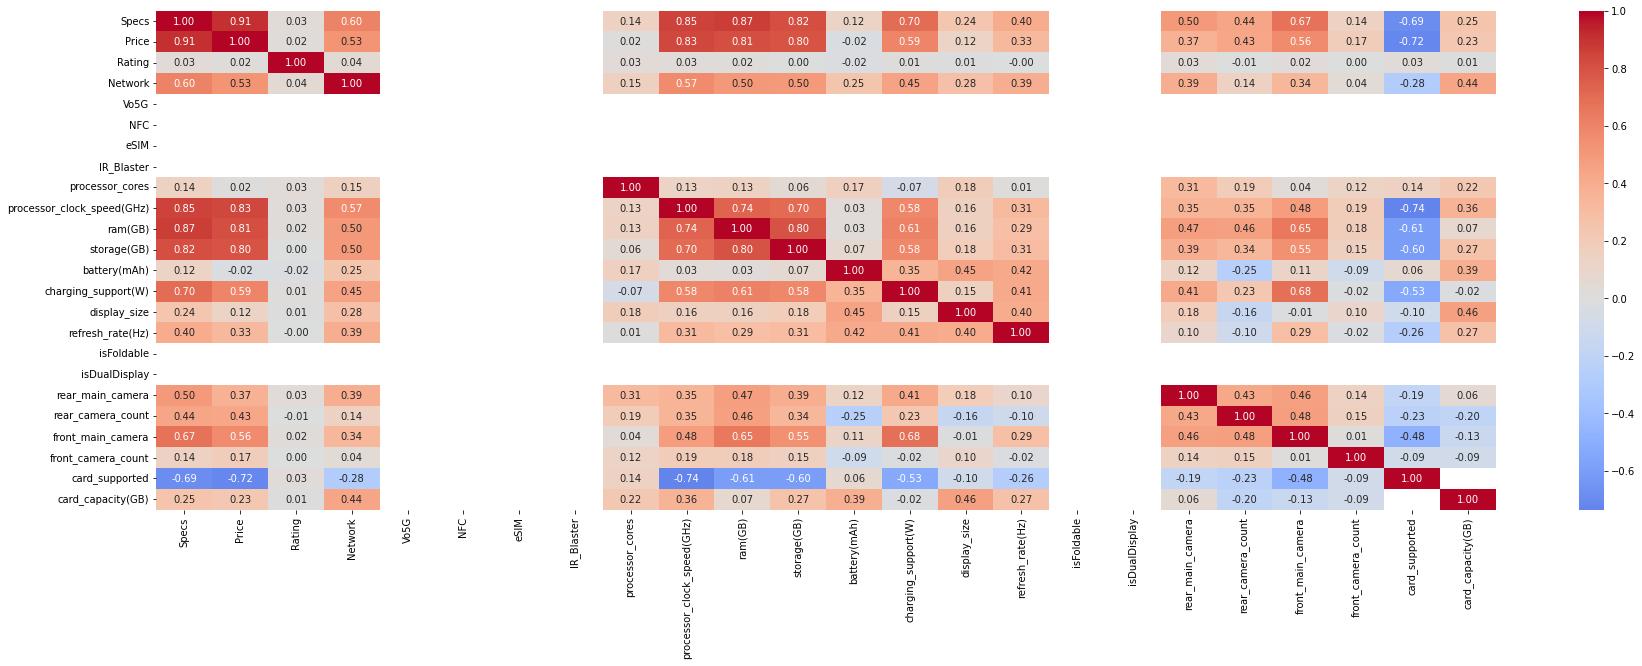

In [77]:
corr = df.corr(numeric_only=True, method="spearman")
plt.figure(figsize=(30, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()

**Points noticed (heatmap) :** the heatmap uses spearman correlation. The blank rows and columns are Vo5G, NFC, eSIM, IR_Blaster, isFoldable and isDualDisplay. They only have 1 or NaN, so there is nothing to calculate. Fixed in the next cell by using fillna(0) first.

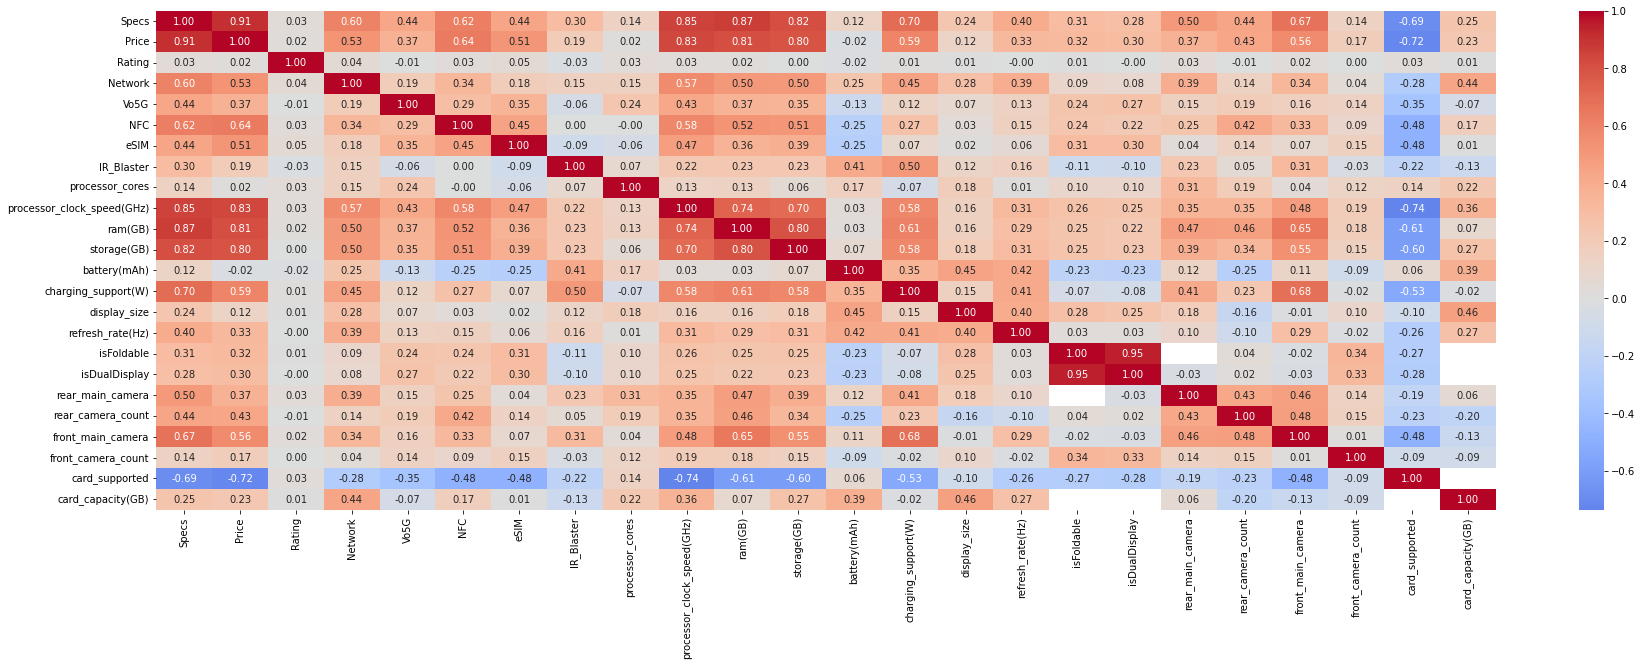

[Text(0.5, 1.0, 'Price correlation with all others columns'),
 Text(0.5, 0, 'Values'),
 Text(0, 0.5, 'Columns')]

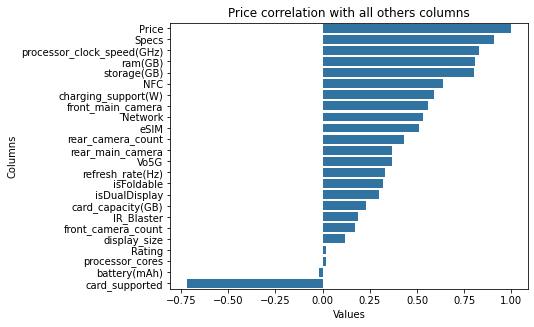

In [78]:
df2 = df.copy()
flags = ['Vo5G', 'eSIM', 'NFC', 'isFoldable', 'isDualDisplay', 'IR_Blaster']
df2[flags] = df2[flags].fillna(0)

corr = df2.corr(numeric_only=True, method="spearman")
plt.figure(figsize=(30, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()

x = corr['Price'].sort_values(ascending=False).round(2)
sns.barplot(x=x.values, y=x.index, orient='h').set(title='Price correlation with all others columns', xlabel='Values', ylabel='Columns')

**Insight (heatmap) :**
  - biggest links with price: clock speed 0.83, ram 0.81, storage 0.80. Then NFC 0.64, charging 0.59, front camera mp 0.56, network (5G) 0.53 and eSIM 0.51.
  - Rating (0.02), processor_cores (0.02) and battery (-0.02) are almost zero, they do not explain price
  - card_supported is the only strong negative one (-0.72). It is even more negative with clock speed (-0.74), ram (-0.61) and storage (-0.60).
  - ram, storage and clock speed are also linked with each other. which is very self explanatory
  

In [79]:

df['price_band'] = pd.cut(df['Price'], [0, 15000, 25000, 40000, 60000, 300000],
                          labels=['<15k', '15-25k', '25-40k', '40-60k', '60k+'])

band_profile = df.groupby('price_band', observed=True).agg(phones=('Price', 'size'),
                                            avg_ram=('ram(GB)', 'median'),
                                             avg_storage=('storage(GB)', 'median'),
                                             avg_clock=('processor_clock_speed(GHz)', 'median'),
                                             avg_battery=('battery(mAh)', 'median'),                                                 avg_charging=('charging_support(W)', 'median'))

nfc_pct = df.groupby('price_band', observed=True)['NFC'].apply(lambda s: s.fillna(0).mean() * 100).rename('NFC_%')
slot_pct = df.groupby('price_band', observed=True)['card_supported'].mean().mul(100).rename('card_slot_%')
pd.concat([band_profile, nfc_pct, slot_pct], axis=1).round(1)

,phones,avg_ram,avg_storage,avg_clock,avg_battery,avg_charging,NFC_%,card_slot_%
price_band,,,,,,,,
<15k,160,4.0,64.0,2.0,5000.0,18.0,2.5,100.0
15-25k,267,6.0,128.0,2.4,6000.0,33.0,24.0,92.3
25-40k,243,8.0,256.0,2.6,5800.0,66.0,44.4,56.3
40-60k,112,12.0,256.0,3.0,5550.0,80.0,80.4,19.4
60k+,135,12.0,256.0,3.8,4832.0,45.0,97.0,1.2


**Insight (price groups) :** this table shows how a phone changes when the price goes up.
  - ram, storage and clock speed increases as price increases which is normal and so obvious
  - NFC% increases as price increases that made him a premium feature which is again very obvious
  - battery and charging do not keep rising: they are also linear with price(as price go higher the capacities go higher too), it's just there are foldable smartphones and dualDisplay smartphones that does not provide much better values because of the foldability concern

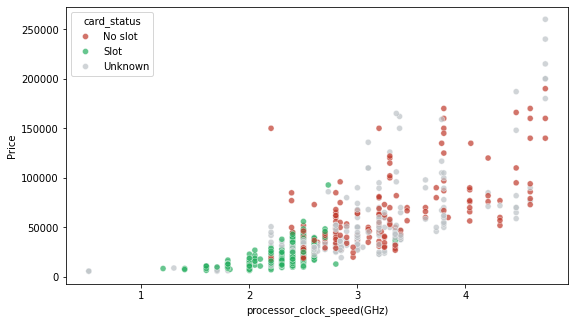

In [80]:
df['card_status'] = df['card_supported'].map({1.0: 'Slot', 0.0: 'No slot'}).fillna('Unknown')

plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='processor_clock_speed(GHz)', y='Price', hue='card_status',
                palette={'Slot': '#27ae60', 'No slot': '#c0392b', 'Unknown': '#bdc3c7'}, alpha=0.7)
plt.show()

**Insight (card slot vs clock speed) :** from the above graph it can be concluded that as fast as processor_speed will be the more chance will there be absence of card_slot, also if there are phones are providing card_slot that are costlier, those phones are older iphones providinig card_slot. but as of today's modern smartphones desgin choice shows that almost all premium phones does not provide card_slot

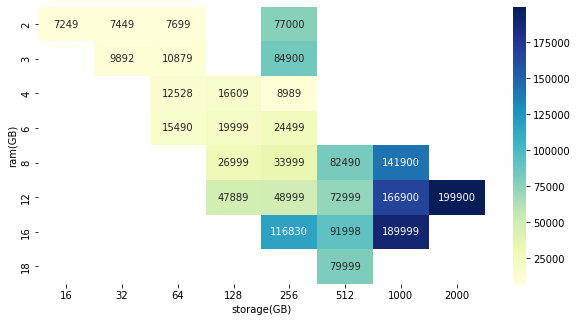

In [81]:
pt = pd.pivot_table(df, values='Price', index='ram(GB)', columns='storage(GB)', aggfunc='median')
plt.figure(figsize=(10, 5))
sns.heatmap(pt, annot=True, fmt='.0f', cmap='YlGnBu')
plt.show()

In [82]:
brand_summary = df.groupby('Brand').agg(phones=('Price', 'size'), median_price=('Price', 'median'),
                                        median_ram=('ram(GB)', 'median'), median_storage=('storage(GB)', 'median'))
nfc_share = df.groupby('Brand')['NFC'].apply(lambda s: s.fillna(0).mean() * 100).rename('NFC_%')
slot_share = df.groupby('Brand')['card_supported'].mean().mul(100).rename('card_slot_%')

brand_summary = pd.concat([brand_summary, nfc_share, slot_share], axis=1)
brand_summary[brand_summary['phones'] >= 15].sort_values('median_price', ascending=False).round(1)

,phones,median_price,median_ram,median_storage,NFC_%,card_slot_%
Brand,,,,,,
Apple,31,87900.0,8.0,256.0,100.0,0.0
Google,19,49999.0,12.0,256.0,100.0,0.0
Oneplus,32,47249.0,8.0,256.0,71.9,37.5
Samsung,166,35749.0,8.0,128.0,73.5,71.5
Nothing,17,35320.0,8.0,256.0,70.6,25.0
Oppo,101,31990.0,8.0,256.0,29.7,77.9
Iqoo,24,31799.0,8.0,256.0,33.3,60.0
Vivo,77,28999.0,8.0,128.0,35.1,41.2
Xiaomi,82,24652.5,8.0,128.0,26.8,82.8


**Insight** : it's worth noticing that brands like google and apple provides NFC feature 100% for sure at least for this dataset

<Axes: xlabel='processor_brand', ylabel='Brand'>

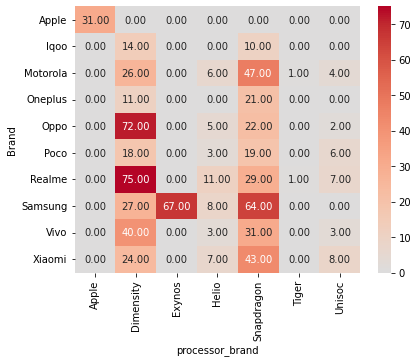

In [83]:
top_brands = df['Brand'].value_counts().head(10).index
x = pd.crosstab(df[df['Brand'].isin(top_brands)]['Brand'], df['processor_brand']) 

sns.heatmap(x, annot=True, fmt=".2f", cmap="coolwarm", center=0)

**Insight (crosstabs) :**
  - Exynos is used only by Samsung (67 phones, and Samsung also uses Snapdragon 64 and Dimensity 27). Realme and Oppo mostly use Dimensity (75 and 72 phones), while Xiaomi, Motorola and OnePlus mostly use Snapdragon
  - NFC is almost only a 5G thing: 51% of 5G phones have NFC but only 6% of 4G phones have it. So NFC, 5G and a higher price all come together